# DURCL Course Project Notebook

This notebook is the single-file deliverable for the Adaptive Environment Selection course project.
It is organized into three parts:

1. **Training pipeline**: dataset access, project-specific training code, scheduler implementation, and the exact heavy-training command path.
2. **Evaluation pipeline**: checked-in result aggregation by default, with an optional checkpoint-based evaluation entrypoint.
3. **Result interpretation**: tables, figures, toy sanity checks, and the written analysis used in the report.

The notebook is designed to be **self-bootstrapping**:

- If it is run inside a cloned copy of the repository, it uses the local files directly.
- If it is run as a standalone notebook, it can download the repository snapshot from GitHub.
- Large artifacts such as model checkpoints are intentionally loaded by link rather than embedded in the notebook.
- It installs a small set of missing Python packages automatically; it does not require a manual conda setup walkthrough.

Heavy RL training is **not executed by default** because it requires a compatible multi-GPU environment, but the code path and command construction are included here so the full workflow is documented in one place.


In [1]:
from __future__ import annotations

import importlib
import json
import math
import os
import shutil
import subprocess
import sys
import textwrap
import urllib.request
import zipfile
from pathlib import Path


def ensure_packages(packages: list[str]) -> None:
    missing = []
    for pkg in packages:
        module = pkg.split("==", 1)[0].split(">=", 1)[0]
        module = {"pillow": "PIL", "pyarrow": "pyarrow"}.get(module, module)
        try:
            importlib.import_module(module)
        except Exception:
            missing.append(pkg)
    if missing:
        print("Installing missing packages:", missing)
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])


ensure_packages([
    "pandas",
    "matplotlib",
    "pillow",
    "pyarrow",
    "reportlab",
    "pytest",
])

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Code, Image, Markdown, display


plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)


In [2]:
RUN_UNIT_TESTS = True
RUN_HEAVY_TRAINING = False
RUN_CHECKPOINT_EVAL = False
INSTALL_TRAINING_EXTRAS = False
PREPARE_MATH_ZEBRA_DATA = False
REGENERATE_FIGURES = False
RERUN_TOY_SIMULATION = False
TRAINING_PROFILE = os.environ.get("AES_TRAINING_PROFILE", "math_zebra_rebucket_globalacc_from80_to200").strip()

REPO_URL = "https://github.com/kkkzzz0101/Adaptive-Env-Selection.git"
REPO_ZIP_URL = "https://github.com/kkkzzz0101/Adaptive-Env-Selection/archive/refs/heads/main.zip"
RAW_BASE = "https://raw.githubusercontent.com/kkkzzz0101/Adaptive-Env-Selection/main"

HF_MODEL_ID = os.environ.get(
    "AES_HF_MODEL_ID",
    "zkkk452/adaptive-env-selection-checkpoint",
).strip()
CHECKPOINT_ARCHIVE_URL = os.environ.get("AES_CHECKPOINT_ARCHIVE_URL", "").strip()
LOCAL_MODEL_PATH = os.environ.get("AES_LOCAL_MODEL_PATH", "").strip()
HF_TOKEN = (
    os.environ.get("HF_TOKEN", "").strip()
    or os.environ.get("HUGGINGFACE_HUB_TOKEN", "").strip()
)

print({
    "RUN_UNIT_TESTS": RUN_UNIT_TESTS,
    "RUN_HEAVY_TRAINING": RUN_HEAVY_TRAINING,
    "RUN_CHECKPOINT_EVAL": RUN_CHECKPOINT_EVAL,
    "INSTALL_TRAINING_EXTRAS": INSTALL_TRAINING_EXTRAS,
    "PREPARE_MATH_ZEBRA_DATA": PREPARE_MATH_ZEBRA_DATA,
    "REGENERATE_FIGURES": REGENERATE_FIGURES,
    "RERUN_TOY_SIMULATION": RERUN_TOY_SIMULATION,
    "TRAINING_PROFILE": TRAINING_PROFILE,
})


{'RUN_UNIT_TESTS': True, 'RUN_HEAVY_TRAINING': False, 'RUN_CHECKPOINT_EVAL': False, 'INSTALL_TRAINING_EXTRAS': False, 'PREPARE_MATH_ZEBRA_DATA': False, 'REGENERATE_FIGURES': False, 'RERUN_TOY_SIMULATION': False, 'TRAINING_PROFILE': 'math_zebra_rebucket_globalacc_from80_to200'}


In [3]:
NOTEBOOK_CWD = Path.cwd()


def github_raw_url(path: str) -> str:
    return f"{RAW_BASE}/{path}"


def find_repo_root(start: Path) -> Path | None:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "README.md").exists() and (candidate / "paper" / "deliverables").exists():
            return candidate
    return None


def download_repo_snapshot(dest_dir: Path) -> Path:
    dest_dir.mkdir(parents=True, exist_ok=True)
    zip_path = dest_dir / "Adaptive-Env-Selection-main.zip"
    extract_dir = dest_dir / "Adaptive-Env-Selection-main"
    if not extract_dir.exists():
        print(f"Downloading repository snapshot from {REPO_ZIP_URL}")
        urllib.request.urlretrieve(REPO_ZIP_URL, zip_path)
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(dest_dir)
    return extract_dir


ROOT = find_repo_root(NOTEBOOK_CWD)
if ROOT is None:
    ROOT = download_repo_snapshot(NOTEBOOK_CWD / "aes_notebook_runtime")
    print(f"Using downloaded repository at: {ROOT}")
else:
    print(f"Using local repository at: {ROOT}")

sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "scripts"))


Using local repository at: /Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo


In [4]:
asset_rows = [
    {"artifact": "Repository root", "path": str(ROOT), "exists": ROOT.exists()},
    {"artifact": "Notebook", "path": str(ROOT / "paper/deliverables/project_groupID.ipynb"), "exists": (ROOT / "paper/deliverables/project_groupID.ipynb").exists()},
    {"artifact": "Math+Zebra data", "path": str(ROOT / "experiments/baselines/data_math_zebra_800"), "exists": (ROOT / "experiments/baselines/data_math_zebra_800").exists()},
    {"artifact": "SEC eval data", "path": str(ROOT / "references/sec/data"), "exists": (ROOT / "references/sec/data").exists()},
    {"artifact": "Scheduler source", "path": str(ROOT / "src/scheduler/adaptive_curriculum_scheduler.py"), "exists": (ROOT / "src/scheduler/adaptive_curriculum_scheduler.py").exists()},
    {"artifact": "Eval probe", "path": str(ROOT / "scripts/sec_inference_probe.py"), "exists": (ROOT / "scripts/sec_inference_probe.py").exists()},
    {"artifact": "Result report", "path": str(ROOT / "docs/result_report.md"), "exists": (ROOT / "docs/result_report.md").exists()},
    {"artifact": "Composition drift summary", "path": str(ROOT / "experiments/results/window_rebucket_globalacc_80_200/composition_drift_summary.json"), "exists": (ROOT / "experiments/results/window_rebucket_globalacc_80_200/composition_drift_summary.json").exists()},
    {"artifact": "Transition matrix summary", "path": str(ROOT / "experiments/results/window_rebucket_globalacc_80_200/inferred_transition_matrix.json"), "exists": (ROOT / "experiments/results/window_rebucket_globalacc_80_200/inferred_transition_matrix.json").exists()},
    {"artifact": "Paper figures", "path": str(ROOT / "paper/figures"), "exists": (ROOT / "paper/figures").exists()},
]
display(pd.DataFrame(asset_rows))


,artifact,path,exists
0,Repository root,/Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo,True
1,Notebook,/Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo/paper/deliverab...,True
2,Math+Zebra data,/Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo/experiments/bas...,False
3,SEC eval data,/Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo/references/sec/...,True
4,Scheduler source,/Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo/src/scheduler/a...,True
5,Eval probe,/Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo/scripts/sec_inf...,True
6,Result report,/Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo/docs/result_rep...,True
7,Composition drift summary,/Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo/experiments/res...,True
8,Transition matrix summary,/Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo/experiments/res...,True
9,Paper figures,/Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo/paper/figures,True


## Part I. Training Pipeline

The final project story is the `math + zebra` line, not the earlier four-dataset SEC4 baseline.
This section therefore centers the training path that leads to the final **window-fitted linear rebucketing** result:

- `math + zebra` data preparation,
- the adaptive scheduler / rebucketing implementation,
- the warm-80 and `80 -> 200` continuation setup,
- and a portable heavy-training command that can be launched from the notebook in a compatible GPU environment.

By default the notebook only documents and previews the pipeline. It launches training only if `RUN_HEAVY_TRAINING=True`.


In [5]:
import pyarrow.parquet as pq

math_zebra_root = ROOT / "experiments" / "baselines" / "data_math_zebra_800" / "mixed"
sec_eval_root = ROOT / "references" / "sec" / "data"

rows = []
for path in [math_zebra_root / "train.parquet", math_zebra_root / "val.parquet"]:
    if path.exists():
        rel = path.relative_to(ROOT).as_posix()
        rows.append({
            "file": rel,
            "rows": pq.read_metadata(path).num_rows,
            "download_url": github_raw_url(rel),
        })

for path in sorted(sec_eval_root.rglob("*.parquet")):
    rel = path.relative_to(ROOT).as_posix()
    rows.append({
        "file": rel,
        "rows": pq.read_metadata(path).num_rows,
        "download_url": github_raw_url(rel),
    })

data_df = pd.DataFrame(rows).sort_values("file").reset_index(drop=True)
display(data_df)


,file,rows,download_url
0,references/sec/data/arc/test.parquet,800,https://raw.githubusercontent.com/kkkzzz0101/Adaptive-Env-Selection/main/references/sec/data/arc/test.parquet
1,references/sec/data/arc/train.parquet,30000,https://raw.githubusercontent.com/kkkzzz0101/Adaptive-Env-Selection/main/references/sec/data/arc/train.parquet
2,references/sec/data/combined/test_arc.parquet,800,https://raw.githubusercontent.com/kkkzzz0101/Adaptive-Env-Selection/main/references/sec/data/combined/test_arc.parquet
3,references/sec/data/combined/test_countdown.parquet,800,https://raw.githubusercontent.com/kkkzzz0101/Adaptive-Env-Selection/main/references/sec/data/combined/test_countdown...
4,references/sec/data/combined/test_zebra.parquet,800,https://raw.githubusercontent.com/kkkzzz0101/Adaptive-Env-Selection/main/references/sec/data/combined/test_zebra.par...
5,references/sec/data/combined/train_arc.parquet,30000,https://raw.githubusercontent.com/kkkzzz0101/Adaptive-Env-Selection/main/references/sec/data/combined/train_arc.parquet
6,references/sec/data/combined/train_countdown.parquet,30000,https://raw.githubusercontent.com/kkkzzz0101/Adaptive-Env-Selection/main/references/sec/data/combined/train_countdow...
7,references/sec/data/combined/train_zebra.parquet,30000,https://raw.githubusercontent.com/kkkzzz0101/Adaptive-Env-Selection/main/references/sec/data/combined/train_zebra.pa...
8,references/sec/data/countdown/test.parquet,800,https://raw.githubusercontent.com/kkkzzz0101/Adaptive-Env-Selection/main/references/sec/data/countdown/test.parquet
9,references/sec/data/countdown/train.parquet,30000,https://raw.githubusercontent.com/kkkzzz0101/Adaptive-Env-Selection/main/references/sec/data/countdown/train.parquet


### Math + Zebra Dataset Composition

The final experiments use a two-source mixture:

- `zebra` difficulties: `1,2,3,4`
- `math` difficulties: `1,2,3,4,5`
- `train_per_bucket = 100`
- `val_per_bucket = 20`
- `test_per_bucket = 0`
- `math_train_per_level = 80`
- `math_val_per_level = 10`

This gives the `math_zebra_800` training set described in the final report path:

- `400` zebra training examples
- `400` math training examples
- `130` validation examples total


In [6]:
def show_source(rel_path: str, start: int = 1, end: int | None = None) -> None:
    path = ROOT / rel_path
    lines = path.read_text(encoding="utf-8").splitlines()
    if end is None:
        end = len(lines)
    snippet = "\n".join(f"{idx:4d}: {line}" for idx, line in enumerate(lines[start - 1:end], start))
    print(f"--- {rel_path} ---")
    print(snippet)


show_source("scripts/prepare_sec4_random_dataset.py", 1, 140)


--- scripts/prepare_sec4_random_dataset.py ---
   1: #!/usr/bin/env python3
   2: from __future__ import annotations
   3: 
   4: import argparse
   5: import ast
   6: import json
   7: import re
   8: from pathlib import Path
   9: from typing import Any, Tuple
  10: 
  11: import numpy as np
  12: import pandas as pd
  13: 
  14: from prompt_protocol import append_protocol_text, extract_countdown_target, infer_dataset_from_data_source
  15: 
  16: REQUIRED_COLUMNS = ["data_source", "prompt", "ability", "reward_model", "extra_info"]
  17: 
  18: 
  19: def _coerce_prompt_messages(prompt: Any) -> list[dict[str, Any]] | None:
  20:     if isinstance(prompt, list):
  21:         return prompt
  22: 
  23:     if hasattr(prompt, "tolist") and not isinstance(prompt, (str, bytes)):
  24:         try:
  25:             obj = prompt.tolist()
  26:             if isinstance(obj, list):
  27:                 return obj
  28:         except Exception:
  29:             pass
  30: 
  31:     if 

In [7]:
show_source("src/scheduler/adaptive_curriculum_scheduler.py", 1, 220)


--- src/scheduler/adaptive_curriculum_scheduler.py ---
   1: from __future__ import annotations
   2: 
   3: from dataclasses import dataclass, field
   4: from typing import Any, Dict, Iterable, List, Mapping, MutableMapping, Optional, Sequence, Tuple
   5: import math
   6: import random
   7: 
   8: 
   9: @dataclass
  10: class SchedulerConfig:
  11:     num_clusters: int = 3
  12:     decay: float = 0.95
  13:     ucb_beta: float = 1.0
  14:     softmax_tau: float = 0.2
  15:     prob_floor_eps: float = 0.05
  16:     warmup_steps: int = 200
  17:     rebucket_interval: int = 50
  18:     active_window: int = 200
  19:     min_obs_for_rebucket: int = 10
  20:     migration_gamma: float = 2.0
  21:     migration_consecutive: int = 3
  22:     allow_only_neighbor_migration: bool = True
  23:     allow_reverse_migration: bool = False
  24:     seed: int = 42
  25: 
  26:     def __post_init__(self) -> None:
  27:         if self.num_clusters < 2:
  28:             raise ValueError("n

In [8]:
SCRIPT_SNIPPETS = {
    "run_scheduler_norebucket_4gpu_mathzebra_globalacc_warm80.sh": '''
CUDA_VISIBLE_DEVICES=0,1,2,3 \
USE_ADAPTIVE_SCHEDULER=1 \
ADAPTIVE_NUM_CLUSTERS=5 \
ADAPTIVE_WARMUP_STEPS=1000000 \
ADAPTIVE_REBUCKET_INTERVAL=20 \
ADAPTIVE_MIN_OBS=8 \
ADAPTIVE_ACTIVE_WINDOW=80 \
ADAPTIVE_DECAY=0.6 \
ADAPTIVE_UCB_BETA=0.85 \
ADAPTIVE_SOFTMAX_TAU=0.2 \
ADAPTIVE_PROB_FLOOR_EPS=0.05 \
ADAPTIVE_MIGRATION_GAMMA=2.0 \
ADAPTIVE_MIGRATION_CONSECUTIVE=2 \
ADAPTIVE_ALLOW_REVERSE_MIGRATION=0 \
ADAPTIVE_REVERSE_MIGRATION_GAMMA=2.5 \
ADAPTIVE_REVERSE_MIGRATION_CONSECUTIVE=4 \
ADAPTIVE_MICRO_BUCKETS_PER_LEVEL=5 \
ADAPTIVE_TARGET_MICRO_BUCKET_SIZE=20 \
ADAPTIVE_TRAJECTORY_WINDOW_OBSERVATIONS=60 \
ADAPTIVE_MIN_GROUP_OBS_PER_WINDOW=8 \
ADAPTIVE_CLUSTER_MIN_MICRO_BUCKETS=2 \
ADAPTIVE_CLUSTER_COOLDOWN_STEPS=40 \
ADAPTIVE_MAX_SWAPS_PER_PAIR=1 \
ADAPTIVE_MAX_MOVES_PER_CLUSTER=1 \
ADAPTIVE_ENABLE_MOVE_SECOND=1 \
python -m verl.trainer.main_ppo ...
    '''.strip(),
    "run_scheduler_norebucket_4gpu_mathzebra_globalacc_from80.sh": '''
CUDA_VISIBLE_DEVICES=0,1,2,3 \
USE_ADAPTIVE_SCHEDULER=1 \
ADAPTIVE_WARMUP_STEPS=1000000 \
ADAPTIVE_IGNORE_CHECKPOINT_STATE=0 \
ADAPTIVE_IGNORE_DATALOADER_CHECKPOINT=1 \
python -m verl.trainer.main_ppo ...  # resume from warm80 -> step 200
    '''.strip(),
    "run_scheduler_microbucket_4gpu_mathzebra_globalacc_from80.sh": '''
CUDA_VISIBLE_DEVICES=0,1,2,3 \
USE_ADAPTIVE_SCHEDULER=1 \
ADAPTIVE_WARMUP_STEPS=80 \
ADAPTIVE_REBUCKET_INTERVAL=20 \
ADAPTIVE_ACTIVE_WINDOW=80 \
ADAPTIVE_TRAJECTORY_WINDOW_OBSERVATIONS=60 \
ADAPTIVE_MIN_GROUP_OBS_PER_WINDOW=8 \
ADAPTIVE_MICRO_BUCKETS_PER_LEVEL=5 \
python -m verl.trainer.main_ppo ...  # window rebucket from warm80 -> step 200
    '''.strip(),
    "run_mathzebra_globalacc_to200_chain.sh": '''
bash run_scheduler_norebucket_4gpu_mathzebra_globalacc_warm80.sh
bash run_scheduler_norebucket_4gpu_mathzebra_globalacc_from80.sh
bash run_scheduler_microbucket_4gpu_mathzebra_globalacc_from80.sh
    '''.strip(),
}

for name, snippet in SCRIPT_SNIPPETS.items():
    print(f"--- {name} ---")
    print(snippet)
    print()


--- run_scheduler_norebucket_4gpu_mathzebra_globalacc_warm80.sh ---
CUDA_VISIBLE_DEVICES=0,1,2,3 USE_ADAPTIVE_SCHEDULER=1 ADAPTIVE_NUM_CLUSTERS=5 ADAPTIVE_WARMUP_STEPS=1000000 ADAPTIVE_REBUCKET_INTERVAL=20 ADAPTIVE_MIN_OBS=8 ADAPTIVE_ACTIVE_WINDOW=80 ADAPTIVE_DECAY=0.6 ADAPTIVE_UCB_BETA=0.85 ADAPTIVE_SOFTMAX_TAU=0.2 ADAPTIVE_PROB_FLOOR_EPS=0.05 ADAPTIVE_MIGRATION_GAMMA=2.0 ADAPTIVE_MIGRATION_CONSECUTIVE=2 ADAPTIVE_ALLOW_REVERSE_MIGRATION=0 ADAPTIVE_REVERSE_MIGRATION_GAMMA=2.5 ADAPTIVE_REVERSE_MIGRATION_CONSECUTIVE=4 ADAPTIVE_MICRO_BUCKETS_PER_LEVEL=5 ADAPTIVE_TARGET_MICRO_BUCKET_SIZE=20 ADAPTIVE_TRAJECTORY_WINDOW_OBSERVATIONS=60 ADAPTIVE_MIN_GROUP_OBS_PER_WINDOW=8 ADAPTIVE_CLUSTER_MIN_MICRO_BUCKETS=2 ADAPTIVE_CLUSTER_COOLDOWN_STEPS=40 ADAPTIVE_MAX_SWAPS_PER_PAIR=1 ADAPTIVE_MAX_MOVES_PER_CLUSTER=1 ADAPTIVE_ENABLE_MOVE_SECOND=1 python -m verl.trainer.main_ppo ...

--- run_scheduler_norebucket_4gpu_mathzebra_globalacc_from80.sh ---
CUDA_VISIBLE_DEVICES=0,1,2,3 USE_ADAPTIVE_SCHEDULER=1 ADA

In [9]:
if RUN_UNIT_TESTS:
    result = subprocess.run(
        [sys.executable, "-m", "pytest", "tests/test_scheduler_unit.py", "-q"],
        cwd=ROOT,
        check=True,
        capture_output=True,
        text=True,
    )
    print(result.stdout)
else:
    print("Skipping unit tests. Set RUN_UNIT_TESTS=True to execute the scheduler sanity suite.")


.......                                                                  [100%]
7 passed in 0.03s



In [10]:
TRAIN_BASE_MODEL = os.environ.get("AES_TRAIN_MODEL_PATH", "Qwen/Qwen2.5-1.5B-Instruct").strip()
CHECKPOINT_ROOT = Path(os.environ.get("AES_CHECKPOINT_ROOT", str(ROOT / "checkpoints"))).resolve()
MATH_ZEBRA_DATA_ROOT = ROOT / "experiments" / "baselines" / "data_math_zebra_800" / "mixed"
VERL_ROOT = ROOT / "references" / "DUMP"

MATH_ZEBRA_DATA_CONFIG = {
    "countdown_levels": "",
    "zebra_levels": "1,2,3,4",
    "arc_levels": "",
    "math_levels": "1,2,3,4,5",
    "train_per_bucket": 100,
    "val_per_bucket": 20,
    "test_per_bucket": 0,
    "math_train_per_level": 80,
    "math_val_per_level": 10,
    "seed": 42,
}

TRAINING_PROFILES = {
    "math_zebra_baseline_step200": {
        "project_name": "aes_baseline_mathzebra",
        "exp_name": "baseline_random_dump_mathzebra800_step200",
        "resume": None,
        "scheduler_env": {},
        "trainer": {"steps": 200, "epochs": 30, "save_freq": 100, "test_freq": 100},
    },
    "math_zebra_norebucket_step200": {
        "project_name": "aes_scheduler_mathzebra",
        "exp_name": "scheduler_norebucket_mathzebra800_step200",
        "resume": None,
        "scheduler_env": {
            "USE_ADAPTIVE_SCHEDULER": "1",
            "ADAPTIVE_NUM_CLUSTERS": "5",
            "ADAPTIVE_WARMUP_STEPS": "1000000",
            "ADAPTIVE_REBUCKET_INTERVAL": "10",
            "ADAPTIVE_MIN_OBS": "6",
            "ADAPTIVE_ACTIVE_WINDOW": "80",
            "ADAPTIVE_DECAY": "0.6",
            "ADAPTIVE_UCB_BETA": "0.85",
            "ADAPTIVE_SOFTMAX_TAU": "0.2",
            "ADAPTIVE_PROB_FLOOR_EPS": "0.05",
            "ADAPTIVE_MIGRATION_GAMMA": "2.0",
            "ADAPTIVE_MIGRATION_CONSECUTIVE": "3",
            "ADAPTIVE_ALLOW_REVERSE_MIGRATION": "0",
            "ADAPTIVE_REVERSE_MIGRATION_GAMMA": "2.5",
            "ADAPTIVE_REVERSE_MIGRATION_CONSECUTIVE": "4",
            "ADAPTIVE_CALIBRATION_JSON": str(ROOT / "experiments" / "scheduler" / "calibration_math_zebra.json"),
            "VERL_CURRICULUM_DIAGNOSTICS": "0",
        },
        "trainer": {"steps": 200, "epochs": 30, "save_freq": 100, "test_freq": 100},
    },
    "math_zebra_norebucket_globalacc_warm80": {
        "project_name": "aes_scheduler_mathzebra_globalacc",
        "exp_name": "scheduler_norebucket_mathzebra800_globalacc_warm80",
        "resume": None,
        "scheduler_env": {
            "USE_ADAPTIVE_SCHEDULER": "1",
            "ADAPTIVE_NUM_CLUSTERS": "5",
            "ADAPTIVE_WARMUP_STEPS": "1000000",
            "ADAPTIVE_REBUCKET_INTERVAL": "20",
            "ADAPTIVE_MIN_OBS": "8",
            "ADAPTIVE_ACTIVE_WINDOW": "80",
            "ADAPTIVE_DECAY": "0.6",
            "ADAPTIVE_UCB_BETA": "0.85",
            "ADAPTIVE_SOFTMAX_TAU": "0.2",
            "ADAPTIVE_PROB_FLOOR_EPS": "0.05",
            "ADAPTIVE_MIGRATION_GAMMA": "2.0",
            "ADAPTIVE_MIGRATION_CONSECUTIVE": "2",
            "ADAPTIVE_ALLOW_REVERSE_MIGRATION": "0",
            "ADAPTIVE_REVERSE_MIGRATION_GAMMA": "2.5",
            "ADAPTIVE_REVERSE_MIGRATION_CONSECUTIVE": "4",
            "ADAPTIVE_MICRO_BUCKETS_PER_LEVEL": "5",
            "ADAPTIVE_TARGET_MICRO_BUCKET_SIZE": "20",
            "ADAPTIVE_TRAJECTORY_WINDOW_OBSERVATIONS": "60",
            "ADAPTIVE_MIN_GROUP_OBS_PER_WINDOW": "8",
            "ADAPTIVE_CLUSTER_MIN_MICRO_BUCKETS": "2",
            "ADAPTIVE_CLUSTER_COOLDOWN_STEPS": "40",
            "ADAPTIVE_MAX_SWAPS_PER_PAIR": "1",
            "ADAPTIVE_MAX_MOVES_PER_CLUSTER": "1",
            "ADAPTIVE_ENABLE_MOVE_SECOND": "1",
            "ADAPTIVE_CALIBRATION_JSON": str(ROOT / "experiments" / "scheduler" / "calibration_math_zebra.json"),
            "VERL_CURRICULUM_DIAGNOSTICS": "0",
        },
        "trainer": {"steps": 80, "epochs": 20, "save_freq": 80, "test_freq": 80},
    },
    "math_zebra_norebucket_globalacc_from80_to200": {
        "project_name": "aes_scheduler_mathzebra_globalacc",
        "exp_name": "scheduler_norebucket_mathzebra800_globalacc_from80_to200",
        "resume": {
            "project_name": "aes_scheduler_mathzebra_globalacc",
            "exp_name": "scheduler_norebucket_mathzebra800_globalacc_warm80",
            "source_step": 80,
        },
        "scheduler_env": {
            "USE_ADAPTIVE_SCHEDULER": "1",
            "ADAPTIVE_NUM_CLUSTERS": "5",
            "ADAPTIVE_WARMUP_STEPS": "1000000",
            "ADAPTIVE_REBUCKET_INTERVAL": "20",
            "ADAPTIVE_MIN_OBS": "8",
            "ADAPTIVE_ACTIVE_WINDOW": "80",
            "ADAPTIVE_DECAY": "0.6",
            "ADAPTIVE_UCB_BETA": "0.85",
            "ADAPTIVE_SOFTMAX_TAU": "0.2",
            "ADAPTIVE_PROB_FLOOR_EPS": "0.05",
            "ADAPTIVE_MIGRATION_GAMMA": "2.0",
            "ADAPTIVE_MIGRATION_CONSECUTIVE": "2",
            "ADAPTIVE_ALLOW_REVERSE_MIGRATION": "0",
            "ADAPTIVE_REVERSE_MIGRATION_GAMMA": "2.5",
            "ADAPTIVE_REVERSE_MIGRATION_CONSECUTIVE": "4",
            "ADAPTIVE_MICRO_BUCKETS_PER_LEVEL": "5",
            "ADAPTIVE_TARGET_MICRO_BUCKET_SIZE": "20",
            "ADAPTIVE_TRAJECTORY_WINDOW_OBSERVATIONS": "60",
            "ADAPTIVE_MIN_GROUP_OBS_PER_WINDOW": "8",
            "ADAPTIVE_CLUSTER_MIN_MICRO_BUCKETS": "2",
            "ADAPTIVE_CLUSTER_COOLDOWN_STEPS": "40",
            "ADAPTIVE_MAX_SWAPS_PER_PAIR": "1",
            "ADAPTIVE_MAX_MOVES_PER_CLUSTER": "1",
            "ADAPTIVE_ENABLE_MOVE_SECOND": "1",
            "ADAPTIVE_IGNORE_CHECKPOINT_STATE": "0",
            "ADAPTIVE_IGNORE_DATALOADER_CHECKPOINT": "1",
            "ADAPTIVE_CALIBRATION_JSON": str(ROOT / "experiments" / "scheduler" / "calibration_math_zebra.json"),
            "VERL_CURRICULUM_DIAGNOSTICS": "0",
        },
        "trainer": {"steps": 200, "epochs": 30, "save_freq": 100, "test_freq": 100},
    },
    "math_zebra_rebucket_globalacc_from80_to200": {
        "project_name": "aes_scheduler_mathzebra_globalacc",
        "exp_name": "scheduler_microbucket_mathzebra800_globalacc_from80_to200",
        "resume": {
            "project_name": "aes_scheduler_mathzebra_globalacc",
            "exp_name": "scheduler_norebucket_mathzebra800_globalacc_warm80",
            "source_step": 80,
        },
        "scheduler_env": {
            "USE_ADAPTIVE_SCHEDULER": "1",
            "ADAPTIVE_NUM_CLUSTERS": "5",
            "ADAPTIVE_WARMUP_STEPS": "80",
            "ADAPTIVE_REBUCKET_INTERVAL": "20",
            "ADAPTIVE_MIN_OBS": "8",
            "ADAPTIVE_ACTIVE_WINDOW": "80",
            "ADAPTIVE_DECAY": "0.6",
            "ADAPTIVE_UCB_BETA": "0.85",
            "ADAPTIVE_SOFTMAX_TAU": "0.2",
            "ADAPTIVE_PROB_FLOOR_EPS": "0.05",
            "ADAPTIVE_MIGRATION_GAMMA": "2.0",
            "ADAPTIVE_MIGRATION_CONSECUTIVE": "2",
            "ADAPTIVE_ALLOW_REVERSE_MIGRATION": "0",
            "ADAPTIVE_REVERSE_MIGRATION_GAMMA": "2.5",
            "ADAPTIVE_REVERSE_MIGRATION_CONSECUTIVE": "4",
            "ADAPTIVE_MICRO_BUCKETS_PER_LEVEL": "5",
            "ADAPTIVE_TARGET_MICRO_BUCKET_SIZE": "20",
            "ADAPTIVE_TRAJECTORY_WINDOW_OBSERVATIONS": "60",
            "ADAPTIVE_MIN_GROUP_OBS_PER_WINDOW": "8",
            "ADAPTIVE_CLUSTER_MIN_MICRO_BUCKETS": "2",
            "ADAPTIVE_CLUSTER_COOLDOWN_STEPS": "40",
            "ADAPTIVE_MAX_SWAPS_PER_PAIR": "1",
            "ADAPTIVE_MAX_MOVES_PER_CLUSTER": "1",
            "ADAPTIVE_ENABLE_MOVE_SECOND": "1",
            "ADAPTIVE_IGNORE_CHECKPOINT_STATE": "0",
            "ADAPTIVE_IGNORE_DATALOADER_CHECKPOINT": "1",
            "ADAPTIVE_CALIBRATION_JSON": str(ROOT / "experiments" / "scheduler" / "calibration_math_zebra.json"),
            "VERL_CURRICULUM_DIAGNOSTICS": "0",
        },
        "trainer": {"steps": 200, "epochs": 30, "save_freq": 100, "test_freq": 50},
    },
}


def environment_report() -> pd.DataFrame:
    rows = []
    for module in ["torch", "transformers", "ray"]:
        try:
            imported = importlib.import_module(module)
            rows.append({"component": module, "ready": True, "detail": getattr(imported, "__version__", "unknown")})
        except Exception as exc:
            rows.append({"component": module, "ready": False, "detail": type(exc).__name__})
    rows.append({"component": "vendored verl", "ready": VERL_ROOT.exists(), "detail": str(VERL_ROOT)})
    try:
        import torch
        rows.append({"component": "cuda_available", "ready": bool(torch.cuda.is_available()), "detail": str(torch.cuda.device_count())})
    except Exception as exc:
        rows.append({"component": "cuda_available", "ready": False, "detail": type(exc).__name__})
    return pd.DataFrame(rows)


if INSTALL_TRAINING_EXTRAS:
    ensure_packages(["transformers", "ray", "sentencepiece", "protobuf"])
    print("Installed lightweight Python extras. Torch/CUDA still needs to match the local GPU runtime.")
else:
    print("Skipping optional training-extra installation. Set INSTALL_TRAINING_EXTRAS=True to install transformers/ray helpers.")

display(environment_report())
print("Training base model:", TRAIN_BASE_MODEL)
print("Training profile:", TRAINING_PROFILE)
print("Checkpoint root:", CHECKPOINT_ROOT)
print("If training starts in a fresh environment, the model downloaded here is the base model:", TRAIN_BASE_MODEL)


Skipping optional training-extra installation. Set INSTALL_TRAINING_EXTRAS=True to install transformers/ray helpers.


,component,ready,detail
0,torch,False,ModuleNotFoundError
1,transformers,False,ModuleNotFoundError
2,ray,False,ModuleNotFoundError
3,vendored verl,True,/Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo/references/DUMP
4,cuda_available,False,ModuleNotFoundError


Training base model: Qwen/Qwen2.5-1.5B-Instruct
Training profile: math_zebra_rebucket_globalacc_from80_to200
Checkpoint root: /Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo/checkpoints
If training starts in a fresh environment, the model downloaded here is the base model: Qwen/Qwen2.5-1.5B-Instruct


In [11]:
prepare_cmd = [
    sys.executable,
    str(ROOT / "scripts" / "prepare_sec4_random_dataset.py"),
    "--countdown-levels", MATH_ZEBRA_DATA_CONFIG["countdown_levels"],
    "--zebra-levels", MATH_ZEBRA_DATA_CONFIG["zebra_levels"],
    "--arc-levels", MATH_ZEBRA_DATA_CONFIG["arc_levels"],
    "--math-levels", MATH_ZEBRA_DATA_CONFIG["math_levels"],
    "--train-per-bucket", str(MATH_ZEBRA_DATA_CONFIG["train_per_bucket"]),
    "--val-per-bucket", str(MATH_ZEBRA_DATA_CONFIG["val_per_bucket"]),
    "--test-per-bucket", str(MATH_ZEBRA_DATA_CONFIG["test_per_bucket"]),
    "--math-train-per-level", str(MATH_ZEBRA_DATA_CONFIG["math_train_per_level"]),
    "--math-val-per-level", str(MATH_ZEBRA_DATA_CONFIG["math_val_per_level"]),
    "--seed", str(MATH_ZEBRA_DATA_CONFIG["seed"]),
    "--out-dir", str(MATH_ZEBRA_DATA_ROOT.parent),
]

print("Math+Zebra data-preparation command:")
print(" ".join(prepare_cmd))

if PREPARE_MATH_ZEBRA_DATA:
    subprocess.run(prepare_cmd, cwd=ROOT, check=True)
else:
    print("Dataset preparation is skipped by default because the checked-in math+zebra parquet files are already available.")


Math+Zebra data-preparation command:
/opt/homebrew/Caskroom/miniconda/base/bin/python /Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo/scripts/prepare_sec4_random_dataset.py --countdown-levels  --zebra-levels 1,2,3,4 --arc-levels  --math-levels 1,2,3,4,5 --train-per-bucket 100 --val-per-bucket 20 --test-per-bucket 0 --math-train-per-level 80 --math-val-per-level 10 --seed 42 --out-dir /Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo/experiments/baselines/data_math_zebra_800
Dataset preparation is skipped by default because the checked-in math+zebra parquet files are already available.


In [12]:
training_profile_df = pd.DataFrame([
    {
        "profile": name,
        "project_name": spec["project_name"],
        "exp_name": spec["exp_name"],
        "resume_from": f"{spec['resume']['exp_name']}@{spec['resume']['source_step']}" if spec["resume"] else "",
        "steps": spec["trainer"]["steps"],
        "test_freq": spec["trainer"]["test_freq"],
        "scheduler": "window rebucket" if "microbucket" in spec["exp_name"] else ("no rebucket" if "scheduler" in spec["exp_name"] else "random baseline"),
    }
    for name, spec in TRAINING_PROFILES.items()
])
display(training_profile_df)


,profile,project_name,exp_name,resume_from,steps,test_freq,scheduler
0,math_zebra_baseline_step200,aes_baseline_mathzebra,baseline_random_dump_mathzebra800_step200,,200,100,random baseline
1,math_zebra_norebucket_step200,aes_scheduler_mathzebra,scheduler_norebucket_mathzebra800_step200,,200,100,no rebucket
2,math_zebra_norebucket_globalacc_warm80,aes_scheduler_mathzebra_globalacc,scheduler_norebucket_mathzebra800_globalacc_warm80,,80,80,no rebucket
3,math_zebra_norebucket_globalacc_from80_to200,aes_scheduler_mathzebra_globalacc,scheduler_norebucket_mathzebra800_globalacc_from80_to200,scheduler_norebucket_mathzebra800_globalacc_warm80@80,200,100,no rebucket
4,math_zebra_rebucket_globalacc_from80_to200,aes_scheduler_mathzebra_globalacc,scheduler_microbucket_mathzebra800_globalacc_from80_to200,scheduler_norebucket_mathzebra800_globalacc_warm80@80,200,50,window rebucket


In [13]:
COMMON_TRAIN_KWARGS = {
    "train_batch_size": 32,
    "val_batch_size": 64,
    "rollout_n": 4,
    "max_prompt_length": 960,
    "max_response_length": 384,
    "actor_ppo_micro_batch_size_per_gpu": 1,
    "critic_ppo_micro_batch_size_per_gpu": 2,
    "critic_forward_micro_batch_size_per_gpu": 2,
    "rollout_micro_batch_size": 2,
    "actor_logprob_micro_batch_size": 1,
    "ref_logprob_micro_batch_size": 1,
    "gpu_memory_utilization": 0.85,
    "max_num_batched_tokens": 16384,
    "max_num_seqs": 2048,
    "n_gpus_per_node": int(os.environ.get("N_GPUS_PER_NODE", "4")),
    "cuda_visible_devices": os.environ.get("CUDA_VISIBLE_DEVICES", "0,1,2,3"),
}


def prepare_resume_link(spec: dict[str, object]) -> None:
    resume = spec["resume"]
    if not resume:
        return
    source_dir = CHECKPOINT_ROOT / str(resume["project_name"]) / str(resume["exp_name"]) / f"global_step_{resume['source_step']}"
    target_dir = CHECKPOINT_ROOT / str(spec["project_name"]) / str(spec["exp_name"])
    target_dir.mkdir(parents=True, exist_ok=True)
    link_path = target_dir / f"global_step_{resume['source_step']}"
    if not link_path.exists():
        link_path.symlink_to(source_dir)
    (target_dir / "latest_checkpointed_iteration.txt").write_text(str(resume["source_step"]), encoding="utf-8")


def build_training_command(profile_name: str) -> tuple[list[str], dict[str, str]]:
    spec = TRAINING_PROFILES[profile_name]
    prepare_resume_link(spec)
    env = os.environ.copy()
    env["CUDA_VISIBLE_DEVICES"] = COMMON_TRAIN_KWARGS["cuda_visible_devices"]
    env["PYTHONPATH"] = str(VERL_ROOT) + os.pathsep + env.get("PYTHONPATH", "")
    env["PYTORCH_CUDA_ALLOC_CONF"] = env.get("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
    env["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = env.get("PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION", "python")
    env.update(spec["scheduler_env"])

    run_dir = CHECKPOINT_ROOT / spec["project_name"] / spec["exp_name"]
    cmd = [
        sys.executable,
        "-m",
        "verl.trainer.main_ppo",
        "algorithm.adv_estimator=grpo",
        f"data.train_files={MATH_ZEBRA_DATA_ROOT / 'train.parquet'}",
        f"data.val_files={MATH_ZEBRA_DATA_ROOT / 'val.parquet'}",
        f"data.train_batch_size={COMMON_TRAIN_KWARGS['train_batch_size']}",
        f"data.val_batch_size={COMMON_TRAIN_KWARGS['val_batch_size']}",
        f"data.enable_curriculum_learning={'True' if spec['scheduler_env'] else 'False'}",
        "data.data_source_key=null",
        f"data.max_prompt_length={COMMON_TRAIN_KWARGS['max_prompt_length']}",
        f"data.max_response_length={COMMON_TRAIN_KWARGS['max_response_length']}",
        f"actor_rollout_ref.model.path={TRAIN_BASE_MODEL}",
        "actor_rollout_ref.model.use_remove_padding=False",
        "actor_rollout_ref.model.enable_gradient_checkpointing=True",
        "actor_rollout_ref.actor.use_dynamic_bsz=True",
        "actor_rollout_ref.actor.optim.lr=1e-6",
        f"actor_rollout_ref.actor.ppo_mini_batch_size={COMMON_TRAIN_KWARGS['train_batch_size']}",
        f"actor_rollout_ref.actor.ppo_micro_batch_size_per_gpu={COMMON_TRAIN_KWARGS['actor_ppo_micro_batch_size_per_gpu']}",
        "actor_rollout_ref.actor.ppo_max_token_len_per_gpu=8192",
        "actor_rollout_ref.actor.use_kl_loss=True",
        "actor_rollout_ref.actor.kl_loss_coef=0.001",
        "actor_rollout_ref.actor.kl_loss_type=low_var_kl",
        "actor_rollout_ref.actor.fsdp_config.param_offload=False",
        "actor_rollout_ref.actor.fsdp_config.optimizer_offload=False",
        "actor_rollout_ref.ref.fsdp_config.param_offload=False",
        f"actor_rollout_ref.ref.log_prob_micro_batch_size_per_gpu={COMMON_TRAIN_KWARGS['ref_logprob_micro_batch_size']}",
        "actor_rollout_ref.ref.log_prob_max_token_len_per_gpu=8192",
        "actor_rollout_ref.rollout.name=hf",
        f"actor_rollout_ref.rollout.n={COMMON_TRAIN_KWARGS['rollout_n']}",
        "actor_rollout_ref.rollout.temperature=1.0",
        "actor_rollout_ref.rollout.top_p=1.0",
        "actor_rollout_ref.rollout.top_k=0",
        "actor_rollout_ref.rollout.do_sample=True",
        "actor_rollout_ref.rollout.tensor_model_parallel_size=1",
        f"+actor_rollout_ref.rollout.micro_batch_size={COMMON_TRAIN_KWARGS['rollout_micro_batch_size']}",
        f"actor_rollout_ref.rollout.log_prob_micro_batch_size_per_gpu={COMMON_TRAIN_KWARGS['actor_logprob_micro_batch_size']}",
        "actor_rollout_ref.rollout.log_prob_max_token_len_per_gpu=8192",
        f"actor_rollout_ref.rollout.gpu_memory_utilization={COMMON_TRAIN_KWARGS['gpu_memory_utilization']}",
        f"actor_rollout_ref.rollout.max_num_batched_tokens={COMMON_TRAIN_KWARGS['max_num_batched_tokens']}",
        f"actor_rollout_ref.rollout.max_num_seqs={COMMON_TRAIN_KWARGS['max_num_seqs']}",
        f"critic.model.path={TRAIN_BASE_MODEL}",
        f"critic.model.tokenizer_path={TRAIN_BASE_MODEL}",
        "critic.model.use_remove_padding=False",
        "critic.model.enable_gradient_checkpointing=False",
        "critic.optim.lr=1e-5",
        f"critic.ppo_micro_batch_size_per_gpu={COMMON_TRAIN_KWARGS['critic_ppo_micro_batch_size_per_gpu']}",
        f"critic.forward_micro_batch_size_per_gpu={COMMON_TRAIN_KWARGS['critic_forward_micro_batch_size_per_gpu']}",
        "critic.ppo_max_token_len_per_gpu=12288",
        "algorithm.kl_ctrl.kl_coef=0.001",
        "trainer.critic_warmup=0",
        "trainer.logger=['console']",
        f"trainer.project_name={spec['project_name']}",
        f"trainer.experiment_name={spec['exp_name']}",
        f"trainer.n_gpus_per_node={COMMON_TRAIN_KWARGS['n_gpus_per_node']}",
        "trainer.nnodes=1",
        f"trainer.default_local_dir={run_dir}",
        "trainer.default_hdfs_dir=null",
        f"trainer.save_freq={spec['trainer']['save_freq']}",
        f"trainer.test_freq={spec['trainer']['test_freq']}",
        f"trainer.total_epochs={spec['trainer']['epochs']}",
        "+trainer.val_before_train=False",
        f"trainer.total_training_steps={spec['trainer']['steps']}",
    ]
    return cmd, env


train_parquet = MATH_ZEBRA_DATA_ROOT / "train.parquet"
val_parquet = MATH_ZEBRA_DATA_ROOT / "val.parquet"
data_ready = train_parquet.exists() and val_parquet.exists()

cmd, env = build_training_command(TRAINING_PROFILE)
print("Training command preview for", TRAINING_PROFILE)
print(" ".join(str(x) for x in cmd[:18]), "...")
print("This profile will download or reuse the base model:", TRAIN_BASE_MODEL)
print("Math+Zebra parquet present:", data_ready)

if RUN_HEAVY_TRAINING:
    if not data_ready:
        raise FileNotFoundError("math+zebra parquet files are missing. Set PREPARE_MATH_ZEBRA_DATA=True or provide train/val parquet files before training.")
    print("Launching heavy RL training. This requires a compatible multi-GPU CUDA environment and vendored verl dependencies.")
    subprocess.run(cmd, cwd=ROOT, env=env, check=True)
else:
    if not data_ready:
        print("Training preview only: the current checkout does not contain math+zebra parquet files, so real training would first require PREPARE_MATH_ZEBRA_DATA=True or externally provided parquet files.")
    print("Heavy RL training is skipped by default. Set RUN_HEAVY_TRAINING=True only after the environment report is ready.")


Training command preview for math_zebra_rebucket_globalacc_from80_to200
/opt/homebrew/Caskroom/miniconda/base/bin/python -m verl.trainer.main_ppo algorithm.adv_estimator=grpo data.train_files=/Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo/experiments/baselines/data_math_zebra_800/mixed/train.parquet data.val_files=/Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo/experiments/baselines/data_math_zebra_800/mixed/val.parquet data.train_batch_size=32 data.val_batch_size=64 data.enable_curriculum_learning=True data.data_source_key=null data.max_prompt_length=960 data.max_response_length=384 actor_rollout_ref.model.path=Qwen/Qwen2.5-1.5B-Instruct actor_rollout_ref.model.use_remove_padding=False actor_rollout_ref.model.enable_gradient_checkpointing=True actor_rollout_ref.actor.use_dynamic_bsz=True actor_rollout_ref.actor.optim.lr=1e-6 actor_rollout_ref.actor.ppo_mini_batch_size=32 ...
This

## Part II. Evaluation Pipeline

The notebook supports two evaluation modes:

1. **Default**: load the checked-in `math + zebra` result summaries already stored in the repository.
2. **Optional checkpoint eval**: load a checkpoint from Hugging Face or a local path and run the SEC inference probe.

This keeps the notebook lightweight for grading while still documenting the eval path for the two checkpoint targets we still care about:

- the `baseline_mathzebra200` family,
- and the `window rebucket` run recovered at step 100.

The default eval story in this notebook focuses on `math` and `zebra`, which is the final project line.

Supported optional checkpoint interfaces:

- `AES_HF_MODEL_ID`: a Hugging Face model repository
- `AES_LOCAL_MODEL_PATH`: a local checkpoint directory in loadable Hugging Face / Transformers format
- `AES_CHECKPOINT_ARCHIVE_URL`: an optional archive link placeholder for future external hosting

Note: raw training directories such as `global_step_*` are useful for recovery, but they are not automatically loadable by the inference probe unless they have first been exported into a standard model directory.

The public checkpoint target reserved for those uploads is:
- `zkkk452/adaptive-env-selection-checkpoint`


### Final Rebucket Run Used In The Submission

The final notebook should center the **window-fitted linear rebucketing method** rather than the earlier rebucketing variants that still appear in some checked-in reports.

The authoritative rebucketing result used in the course submission is:

- `rebucket 80 -> 200`
- step 100: `math = 0.440`, `zebra = 0.237`
- step 150: `math = 0.520`, `zebra = 0.237`
- step 200: `math = 0.580`, `zebra = 0.300`

The final comparison shown below focuses on the **step-200** result.


In [14]:
rebucket_json = json.loads(
    (
        ROOT
        / "experiments"
        / "results"
        / "window_rebucket_globalacc_80_200"
        / "window_rebucket_validation_results.json"
    ).read_text(encoding="utf-8")
)
final_rebucket = pd.DataFrame(rebucket_json["metrics"])
final_rebucket["run"] = rebucket_json["run"]
display(final_rebucket)


,step,math_train,zebra_train,run
0,100,0.44,0.237,rebucket_window_linear_80_200
1,150,0.52,0.237,rebucket_window_linear_80_200
2,200,0.58,0.300,rebucket_window_linear_80_200


,step,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4
0,60,0.329,0.301,0.259,0.238,0.230
1,80,0.250,0.264,0.243,0.252,0.235
2,100,0.190,0.210,0.250,0.256,0.220
3,120,0.135,0.189,0.204,0.275,0.216
4,140,0.072,0.148,0.176,0.275,0.257
5,160,0.101,0.141,0.184,0.233,0.255
6,180,0.034,0.106,0.197,0.225,0.264
7,200,0.081,0.101,0.182,0.295,0.253


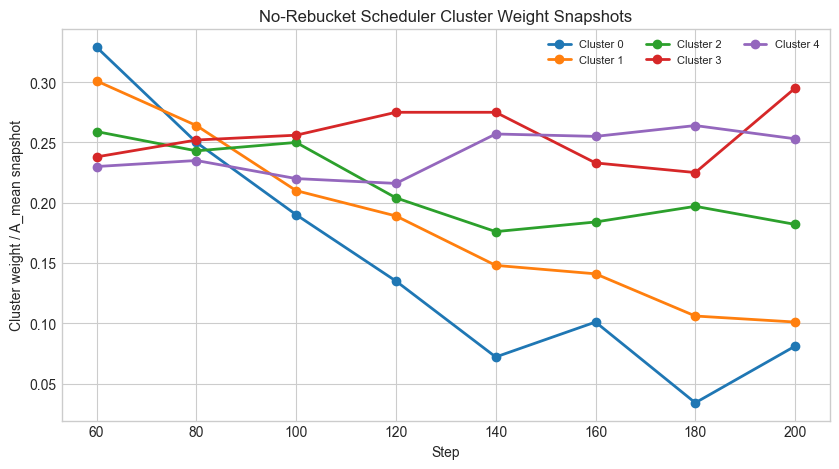

In [15]:
cluster_snapshot_json = json.loads(
    (
        ROOT
        / "experiments"
        / "results"
        / "window_rebucket_globalacc_80_200"
        / "norebucket_cluster_weight_snapshots.json"
    ).read_text(encoding="utf-8")
)
cluster_snapshot_df = pd.DataFrame(cluster_snapshot_json["clusters"])
display(cluster_snapshot_df)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
cluster_cols = [c for c in cluster_snapshot_df.columns if c.startswith("cluster_")]
for col in cluster_cols:
    ax.plot(
        cluster_snapshot_df["step"],
        cluster_snapshot_df[col],
        marker="o",
        linewidth=2,
        label=col.replace("_", " ").title(),
    )
ax.set_title("No-Rebucket Scheduler Cluster Weight Snapshots")
ax.set_xlabel("Step")
ax.set_ylabel("Cluster weight / A_mean snapshot")
ax.legend(ncol=3, fontsize=8)
ax.set_xticks(cluster_snapshot_df["step"].tolist())
plt.tight_layout()
plt.show()


In [16]:
mz = pd.read_csv(ROOT / "experiments" / "results" / "math_zebra_2data" / "baseline_vs_norebucket_metrics.csv")
display(mz)

norebucket = mz[mz["run"] == "scheduler_no_rebucket"][["step", "math_train", "zebra_train"]].copy()
norebucket = norebucket.rename(columns={"math_train": "math_no_rebucket", "zebra_train": "zebra_no_rebucket"})

rebucket_compare = final_rebucket[["step", "math_train", "zebra_train"]].copy()
rebucket_compare = rebucket_compare.rename(columns={"math_train": "math_rebucket", "zebra_train": "zebra_rebucket"})

trajectory_comparison = pd.merge(norebucket, rebucket_compare, on="step", how="outer").sort_values("step").reset_index(drop=True)
display(trajectory_comparison)

step200 = mz[mz["step"] == 200].copy()
baseline = step200[step200["run"] == "baseline_random"].iloc[0]
scheduler = step200[step200["run"] == "scheduler_no_rebucket"].iloc[0]
rebucket = final_rebucket[final_rebucket["step"] == 200].iloc[0]

final_comparison = pd.DataFrame([
    {
        "task": "Math",
        "random_step200": baseline["math_train"],
        "no_rebucket_step200": scheduler["math_train"],
        "rebucket_80_200_step200": rebucket["math_train"],
        "rebucket_vs_random": rebucket["math_train"] - baseline["math_train"],
        "rebucket_vs_no_rebucket": rebucket["math_train"] - scheduler["math_train"],
    },
    {
        "task": "Zebra",
        "random_step200": baseline["zebra_train"],
        "no_rebucket_step200": scheduler["zebra_train"],
        "rebucket_80_200_step200": rebucket["zebra_train"],
        "rebucket_vs_random": rebucket["zebra_train"] - baseline["zebra_train"],
        "rebucket_vs_no_rebucket": rebucket["zebra_train"] - scheduler["zebra_train"],
    },
])
display(final_comparison)


,run,step,math_train,zebra_train
0,baseline_random,100,0.44,0.263
1,baseline_random,200,0.46,0.250
2,scheduler_no_rebucket,60,0.44,0.250
3,scheduler_no_rebucket,100,0.42,0.237
4,scheduler_no_rebucket,200,0.48,0.338


,step,math_no_rebucket,zebra_no_rebucket,math_rebucket,zebra_rebucket
0,60,0.44,0.250,NaN,NaN
1,100,0.42,0.237,0.44,0.237
2,150,NaN,NaN,0.52,0.237
3,200,0.48,0.338,0.58,0.300


,task,random_step200,no_rebucket_step200,rebucket_80_200_step200,rebucket_vs_random,rebucket_vs_no_rebucket
0,Math,0.46,0.480,0.58,0.12,0.100
1,Zebra,0.25,0.338,0.30,0.05,-0.038


,run,step,math_train,zebra_train
0,random baseline,200,0.46,0.250
1,no rebucket,200,0.48,0.338
2,window rebucket,100,0.44,0.237
3,window rebucket,150,0.52,0.237
4,window rebucket,200,0.58,0.300


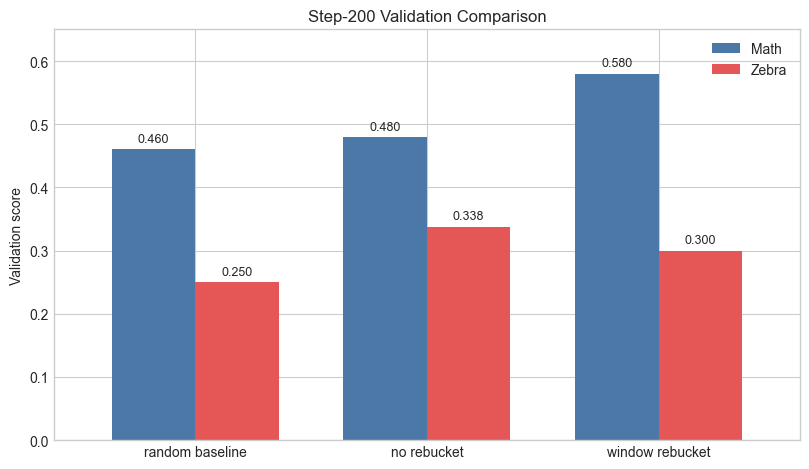

In [17]:
final_result_table = pd.DataFrame([
    {
        "run": "random baseline",
        "step": 200,
        "math_train": baseline["math_train"],
        "zebra_train": baseline["zebra_train"],
    },
    {
        "run": "no rebucket",
        "step": 200,
        "math_train": scheduler["math_train"],
        "zebra_train": scheduler["zebra_train"],
    },
    {
        "run": "window rebucket",
        "step": 100,
        "math_train": final_rebucket.loc[final_rebucket["step"] == 100, "math_train"].iloc[0],
        "zebra_train": final_rebucket.loc[final_rebucket["step"] == 100, "zebra_train"].iloc[0],
    },
    {
        "run": "window rebucket",
        "step": 150,
        "math_train": final_rebucket.loc[final_rebucket["step"] == 150, "math_train"].iloc[0],
        "zebra_train": final_rebucket.loc[final_rebucket["step"] == 150, "zebra_train"].iloc[0],
    },
    {
        "run": "window rebucket",
        "step": 200,
        "math_train": rebucket["math_train"],
        "zebra_train": rebucket["zebra_train"],
    },
])
display(final_result_table)

step200_plot_df = final_result_table[final_result_table["step"] == 200].copy()
step200_plot_df = step200_plot_df.set_index("run")[["math_train", "zebra_train"]]

fig, ax = plt.subplots(figsize=(8.2, 4.8))
step200_plot_df.plot(kind="bar", ax=ax, color=["#4C78A8", "#E45756"], width=0.72)
ax.set_title("Step-200 Validation Comparison")
ax.set_xlabel("")
ax.set_ylabel("Validation score")
ax.set_ylim(0, 0.65)
ax.legend(["Math", "Zebra"], frameon=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


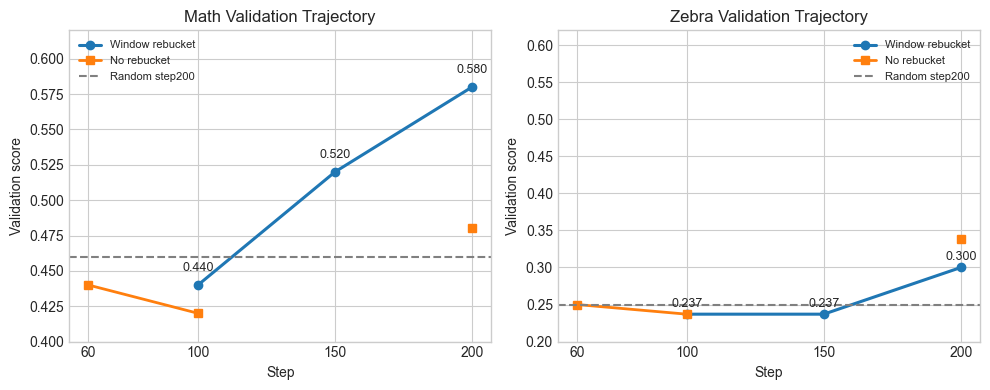

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, task in zip(axes, ["math_train", "zebra_train"]):
    task_label = "Math" if task == "math_train" else "Zebra"
    nr_col = "math_no_rebucket" if task == "math_train" else "zebra_no_rebucket"
    ax.plot(final_rebucket["step"], final_rebucket[task], marker="o", linewidth=2.2, label="Window rebucket")
    ax.plot(trajectory_comparison["step"], trajectory_comparison[nr_col], marker="s", linewidth=2.0, label="No rebucket")
    baseline_step200 = 0.46 if task == "math_train" else 0.25
    ax.axhline(baseline_step200, linestyle="--", linewidth=1.5, color="gray", label="Random step200")
    ax.set_title(f"{task_label} Validation Trajectory")
    ax.set_xlabel("Step")
    ax.set_ylabel("Validation score")
    ax.set_xticks(sorted(set(trajectory_comparison["step"].dropna().tolist() + final_rebucket["step"].tolist())))
    ax.set_ylim(0.20 if task == "zebra_train" else 0.40, 0.62)
    for _, row in final_rebucket.iterrows():
        ax.text(row["step"], row[task] + 0.01, f"{row[task]:.3f}", ha="center", fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### Report Figures Reconstructed Inside The Notebook

The report uses two structural diagnostics to explain why rebucketing matters:

- **composition drift** under difficulty-label initialization,
- and the **inferred transition matrix** from initial to final micro-bucket clusters.

Instead of only embedding the paper PNG files, the notebook recreates these figures from checked-in structured data so the source numbers remain inspectable.


,Math,Zebra,total
C0,5,5,10
C1,5,5,10
C2,5,5,10
C3,5,5,10
C4,5,0,5


,Math,Zebra,total
C0,8,6,14
C1,2,6,8
C2,6,5,11
C3,5,3,8
C4,4,0,4


,Math,Zebra,total
C0,80,100,180
C1,80,100,180
C2,80,100,180
C3,80,100,180
C4,80,0,80


,Math,Zebra,total
C0,128,120,248
C1,32,120,152
C2,96,100,196
C3,80,60,140
C4,64,0,64


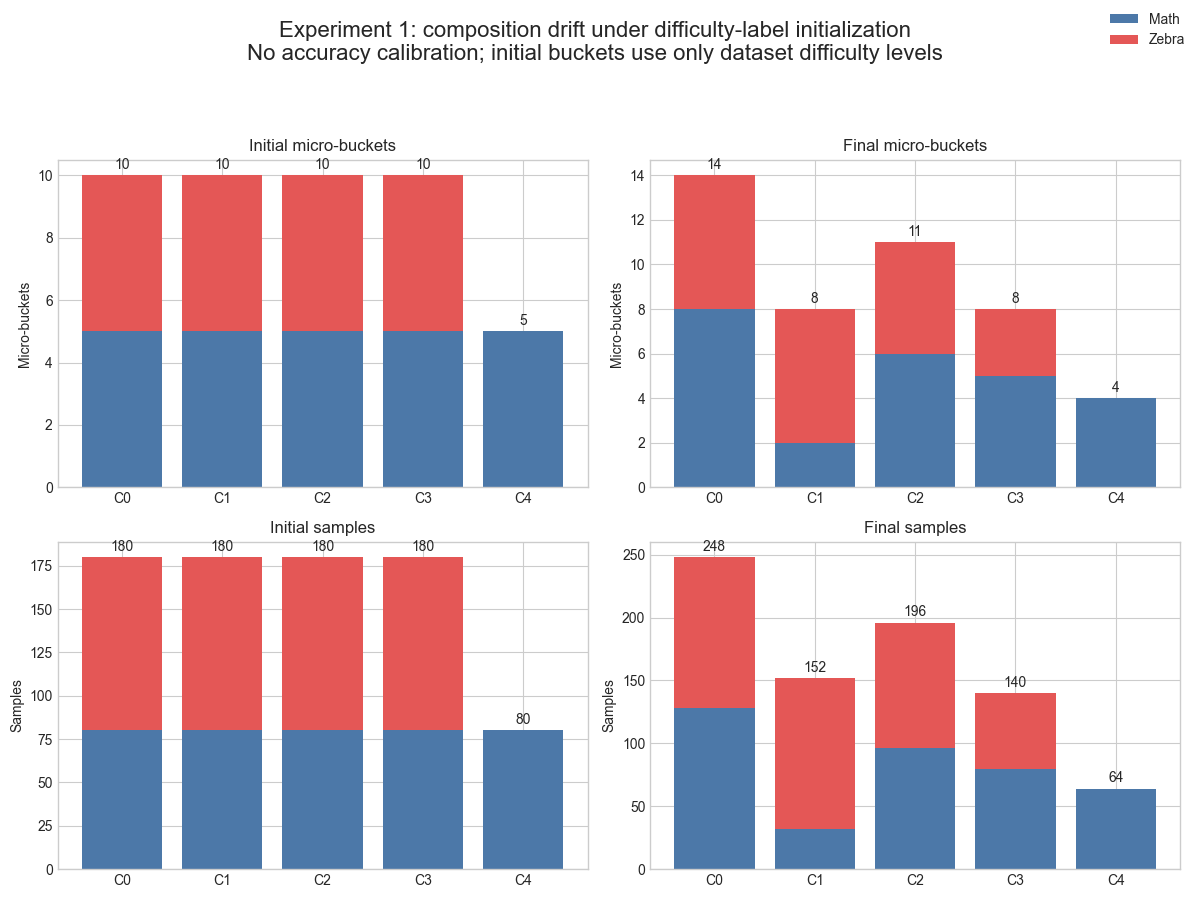

In [19]:
composition_summary = json.loads(
    (
        ROOT
        / "experiments"
        / "results"
        / "window_rebucket_globalacc_80_200"
        / "composition_drift_summary.json"
    ).read_text(encoding="utf-8")
)

cluster_labels = composition_summary["clusters"]
composition_tables = {}
for key in ["initial_micro_buckets", "final_micro_buckets", "initial_samples", "final_samples"]:
    frame = pd.DataFrame(composition_summary[key], index=cluster_labels)
    frame["total"] = frame.sum(axis=1)
    composition_tables[key] = frame

display(composition_tables["initial_micro_buckets"])
display(composition_tables["final_micro_buckets"])
display(composition_tables["initial_samples"])
display(composition_tables["final_samples"])

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
panel_order = [
    ("initial_micro_buckets", "Initial micro-buckets", "Micro-buckets"),
    ("final_micro_buckets", "Final micro-buckets", "Micro-buckets"),
    ("initial_samples", "Initial samples", "Samples"),
    ("final_samples", "Final samples", "Samples"),
]
colors = {"Math": "#4C78A8", "Zebra": "#E45756"}

for ax, (key, title, ylabel) in zip(axes.flatten(), panel_order):
    frame = composition_tables[key]
    bottom = [0] * len(frame)
    for task in ["Math", "Zebra"]:
        values = frame[task].tolist()
        ax.bar(frame.index, values, bottom=bottom, color=colors[task], label=task)
        bottom = [a + b for a, b in zip(bottom, values)]
    for idx, total in enumerate(frame["total"].tolist()):
        ax.text(idx, total + max(frame["total"]) * 0.02, f"{int(total)}", ha="center", fontsize=10)
    ax.set_title(title)
    ax.set_ylabel(ylabel)

fig.suptitle(
    "Experiment 1: composition drift under difficulty-label initialization\n"
    "No accuracy calibration; initial buckets use only dataset difficulty levels",
    fontsize=16,
    y=0.98,
)
handles, labels = axes[0, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", frameon=False)
plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()


,C0,C1,C2,C3,C4
C0,5,0,0,0,0
C1,3,2,0,0,0
C2,0,0,5,0,0
C3,0,0,1,4,0
C4,0,0,0,1,4


,C0,C1,C2,C3,C4
C0,5,0,0,0,0
C1,1,4,0,0,0
C2,0,2,3,0,0
C3,0,0,2,3,0
C4,0,0,0,0,0


/var/folders/pn/xqtfbkbj3mn2d_l39tdl48mw0000gn/T/ipykernel_92034/2939409864.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=(0, 0, 1, 0.90))


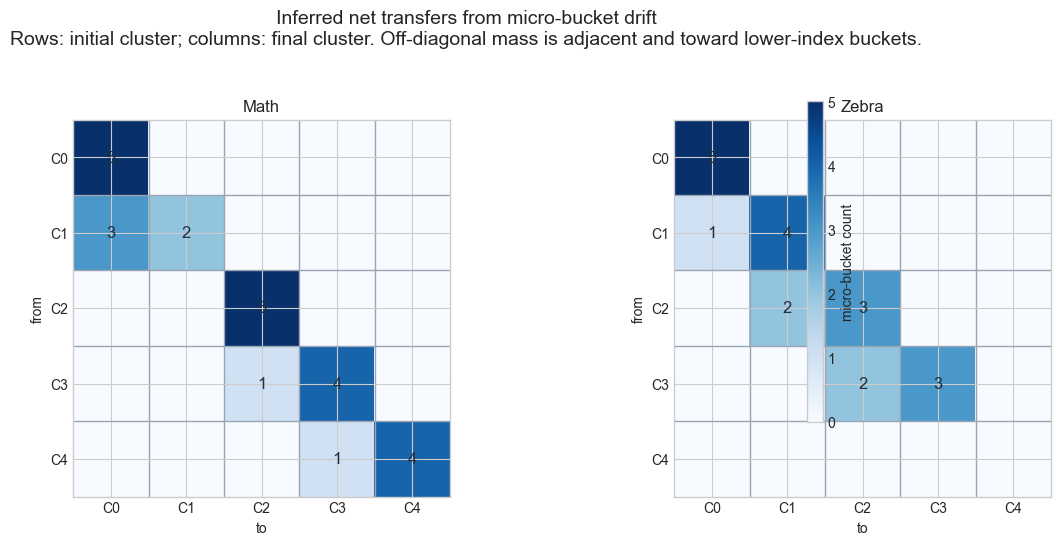

Examples: Math C1 -> C0 = 3; Zebra C3 -> C2 = 2. This is inferred from aggregate composition, not raw event logs.


In [20]:
transition_summary = json.loads(
    (
        ROOT
        / "experiments"
        / "results"
        / "window_rebucket_globalacc_80_200"
        / "inferred_transition_matrix.json"
    ).read_text(encoding="utf-8")
)

cluster_labels = transition_summary["clusters"]
transition_tables = {
    task: pd.DataFrame(transition_summary[task], index=cluster_labels, columns=cluster_labels)
    for task in ["Math", "Zebra"]
}
display(transition_tables["Math"])
display(transition_tables["Zebra"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
cmap = plt.cm.Blues
vmax = max(table.to_numpy().max() for table in transition_tables.values())

for ax, task in zip(axes, ["Math", "Zebra"]):
    frame = transition_tables[task]
    im = ax.imshow(frame.to_numpy(), cmap=cmap, vmin=0, vmax=vmax)
    ax.set_title(task)
    ax.set_xticks(range(len(cluster_labels)), cluster_labels)
    ax.set_yticks(range(len(cluster_labels)), cluster_labels)
    ax.set_xlabel("to")
    ax.set_ylabel("from")
    ax.set_xticks([x - 0.5 for x in range(1, len(cluster_labels))], minor=True)
    ax.set_yticks([y - 0.5 for y in range(1, len(cluster_labels))], minor=True)
    ax.grid(which="minor", color="#9AA4B2", linewidth=1.0)
    ax.tick_params(which="minor", bottom=False, left=False)
    for i in range(frame.shape[0]):
        for j in range(frame.shape[1]):
            value = int(frame.iat[i, j])
            if value:
                ax.text(j, i, str(value), ha="center", va="center", fontsize=12, color="#22313F")

fig.suptitle(
    "Inferred net transfers from micro-bucket drift\n"
    "Rows: initial cluster; columns: final cluster. Off-diagonal mass is adjacent and toward lower-index buckets.",
    fontsize=14,
    y=0.98,
)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="micro-bucket count")
plt.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

print("Examples: Math C1 -> C0 = 3; Zebra C3 -> C2 = 2. This is inferred from aggregate composition, not raw event logs.")


In [21]:
recovered_inventory = pd.read_csv(
    ROOT / "experiments" / "results" / "window_rebucket_globalacc_80_200" / "checkpoint_inventory.csv"
)
recovered_signature = pd.read_csv(
    ROOT / "experiments" / "results" / "window_rebucket_globalacc_80_200" / "step100_signature_summary.csv"
)

display(recovered_inventory)
display(recovered_signature)


,run,step,has_actor_weights,has_curriculum_state,has_data_pt,has_actor_hf_dir,is_complete,notes
0,warm80_norebucket,80,1,1,1,1,1,Source warmup checkpoint; used to seed both follow-on runs
1,norebucket_globalacc_from80_to200,100,1,1,1,1,1,Complete checkpoint
2,norebucket_globalacc_from80_to200,150,0,0,0,0,0,No global_step_150 directory found on recovered machine
3,norebucket_globalacc_from80_to200,200,1,1,1,1,1,Complete checkpoint
4,microbucket_globalacc_from80_to200,100,1,1,1,1,1,Complete checkpoint; latest_checkpointed_iteration points here
5,microbucket_globalacc_from80_to200,150,0,0,0,0,0,No global_step_150 directory found on recovered machine
6,microbucket_globalacc_from80_to200,200,1,0,0,0,0,Actor weights exist but curriculum_state.pt/data.pt are missing


,micro_bucket_id,task_id,current_cluster_id,initial_cluster_id,signature_step,level,slope,volatility,window_obs_count,candidate_target_cluster,candidate_streak,candidate_margin,migration_events
0,math::c0::b0,math,0,0,100,0.280026,-0.000079,0.310109,352,NaN,0,0.000000,0
1,math::c0::b1,math,0,0,100,0.360979,0.002167,0.325419,344,NaN,0,0.000000,0
2,math::c0::b2,math,0,0,100,0.358148,0.000406,0.301840,388,NaN,0,0.000000,0
3,math::c0::b3,math,0,0,100,0.467932,0.002351,0.321039,332,NaN,0,0.000000,0
4,math::c0::b4,math,0,0,100,0.283274,0.001929,0.276533,352,1.0,1,0.709787,0
5,math::c0::b5,math,0,0,100,0.353394,-0.000517,0.301249,420,NaN,0,0.000000,0
6,math::c0::b6,math,0,0,100,0.444594,0.002350,0.287409,352,NaN,0,0.000000,0
7,math::c0::b7,math,0,0,100,0.320198,-0.002186,0.293097,408,NaN,0,0.000000,0
8,math::c1::b0,math,1,1,100,0.157075,0.002890,0.281905,216,NaN,0,0.000000,0
9,math::c1::b1,math,1,1,100,0.241431,0.002598,0.324127,196,NaN,0,0.000000,0


In [22]:
def ensure_eval_dependencies() -> None:
    ensure_packages(["transformers", "torch"])


def resolve_model_reference(root: Path) -> str:
    if HF_MODEL_ID:
        return HF_MODEL_ID
    if LOCAL_MODEL_PATH:
        return LOCAL_MODEL_PATH
    if CHECKPOINT_ARCHIVE_URL:
        archive_dir = root / "artifacts" / "downloaded_checkpoint"
        archive_dir.mkdir(parents=True, exist_ok=True)
        archive_path = archive_dir / "checkpoint_archive"
        if not archive_path.exists():
            print(f"Downloading checkpoint archive from {CHECKPOINT_ARCHIVE_URL}")
            urllib.request.urlretrieve(CHECKPOINT_ARCHIVE_URL, archive_path)
        raise ValueError("Downloaded checkpoint archives should be extracted manually or provided as AES_LOCAL_MODEL_PATH.")
    raise ValueError("No checkpoint source configured. Set AES_HF_MODEL_ID or AES_LOCAL_MODEL_PATH.")


if RUN_CHECKPOINT_EVAL:
    ensure_eval_dependencies()
    model_ref = resolve_model_reference(ROOT)
    probe_out = ROOT / "experiments" / "notebook_eval"
    env = os.environ.copy()
    env["AES_ROOT"] = str(ROOT)
    env["AES_MODEL_PATH"] = model_ref
    if HF_TOKEN:
        env["HF_TOKEN"] = HF_TOKEN
        env["HUGGINGFACE_HUB_TOKEN"] = HF_TOKEN

    datasets = [x.strip() for x in os.environ.get("AES_EVAL_DATASETS", "zebra,math").split(",") if x.strip()]
    for dataset in datasets:
        cmd = [
            sys.executable,
            str(ROOT / "scripts" / "sec_inference_probe.py"),
            "--dataset",
            dataset,
            "--model-path",
            model_ref,
            "--sec-root",
            str(ROOT / "references" / "sec" / "data"),
            "--out-dir",
            str(probe_out / dataset),
            "--n-per-difficulty",
            "10",
            "--rollouts",
            "1",
        ]
        print("Running:", " ".join(cmd))
        subprocess.run(cmd, cwd=ROOT, env=env, check=True)

    summaries = sorted(probe_out.rglob("*_summary.csv"))
    display(pd.DataFrame({"summary_csv": [p.relative_to(ROOT).as_posix() for p in summaries]}))
else:
    print(
        "Checkpoint eval is disabled. To enable it, set RUN_CHECKPOINT_EVAL=True. "
        f"The current default Hugging Face target is: {HF_MODEL_ID}"
    )


Checkpoint eval is disabled. To enable it, set RUN_CHECKPOINT_EVAL=True. The current default Hugging Face target is: zkkk452/adaptive-env-selection-checkpoint


## Part III. Result Interpretation

This section keeps only the report context that still matches the final submission story.
Some checked-in documents were written before the final `rebucket 80 -> 200` result was available, so the notebook should not treat every older report number as authoritative.

The current notebook should therefore:

- use the final `rebucket 80 -> 200` step-200 result as the main rebucketing outcome,
- use the checked-in random and no-rebucket CSV as the baseline comparison source,
- and keep older rebucketing writeups only as background context.

The guiding idea is that the notebook should serve as a compact, inspectable version of the repository for course submission.


In [23]:
checked_in_report_note = pd.DataFrame([
    {
        "file": "docs/result_report.md",
        "status": "outdated for final notebook",
        "reason": "still summarizes the older difficulty-init rebucketing numbers",
    },
    {
        "file": "docs/course_project_report.md",
        "status": "outdated for final notebook",
        "reason": "still highlights the earlier 0.540 / 0.300 acc-init rebucketing result",
    },
    {
        "file": "README.md",
        "status": "partially outdated",
        "reason": "contains older rebucketing highlights and should not override the final 80->200 submission result",
    },
])
display(checked_in_report_note)


,file,status,reason
0,docs/result_report.md,outdated for final notebook,still summarizes the older difficulty-init rebucketing numbers
1,docs/course_project_report.md,outdated for final notebook,still highlights the earlier 0.540 / 0.300 acc-init rebucketing result
2,README.md,partially outdated,contains older rebucketing highlights and should not override the final 80->200 submission result


Using checked-in figures. Set REGENERATE_FIGURES=True to rebuild them.


### fig_method_pipeline

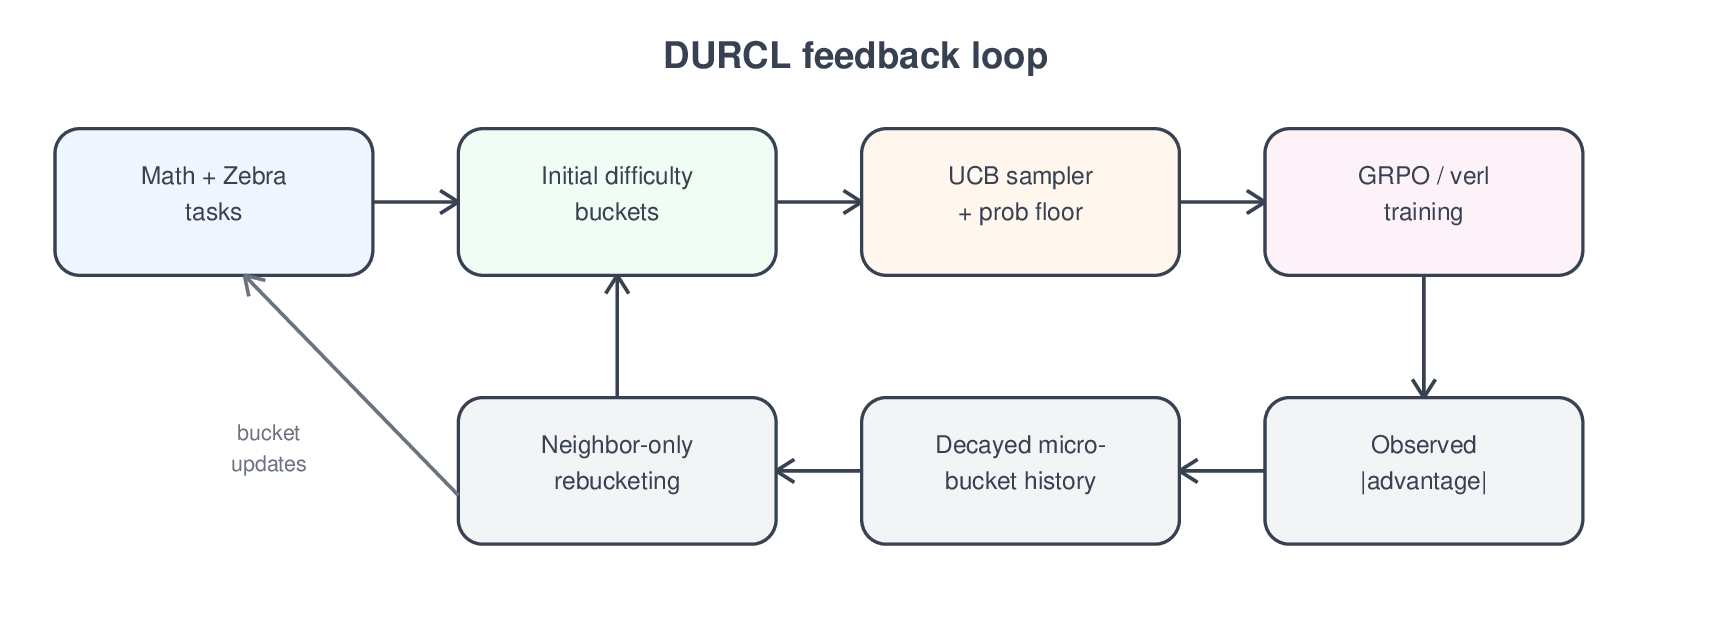

### fig_step200_math_zebra

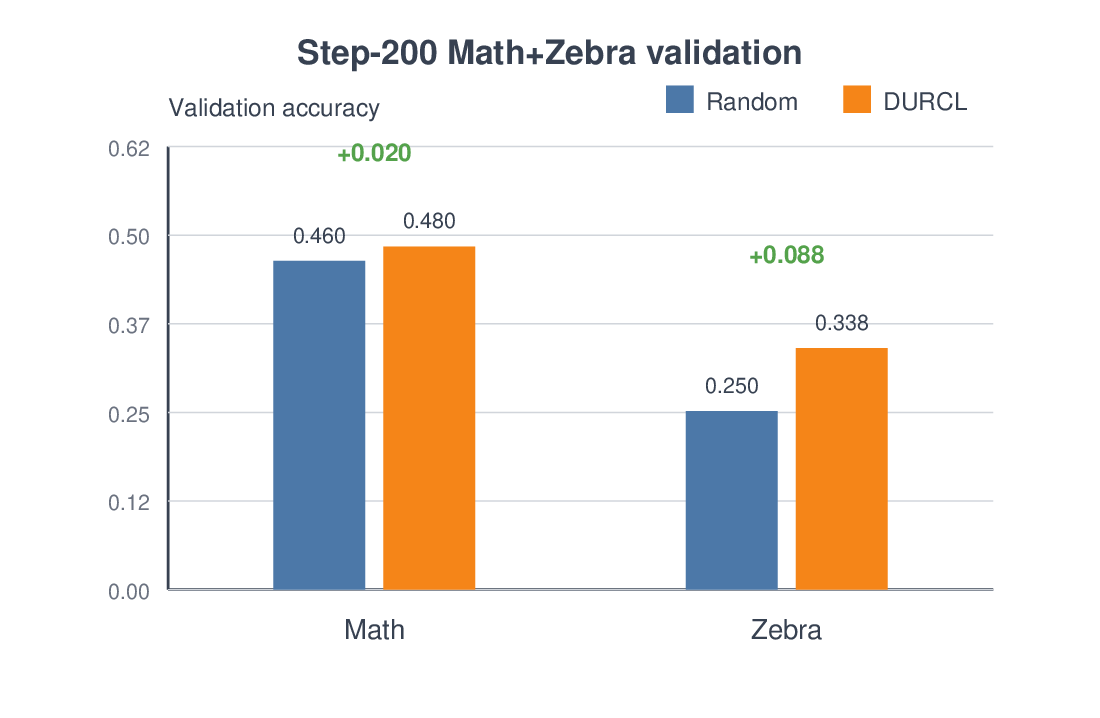

### fig_ucb_score_drift

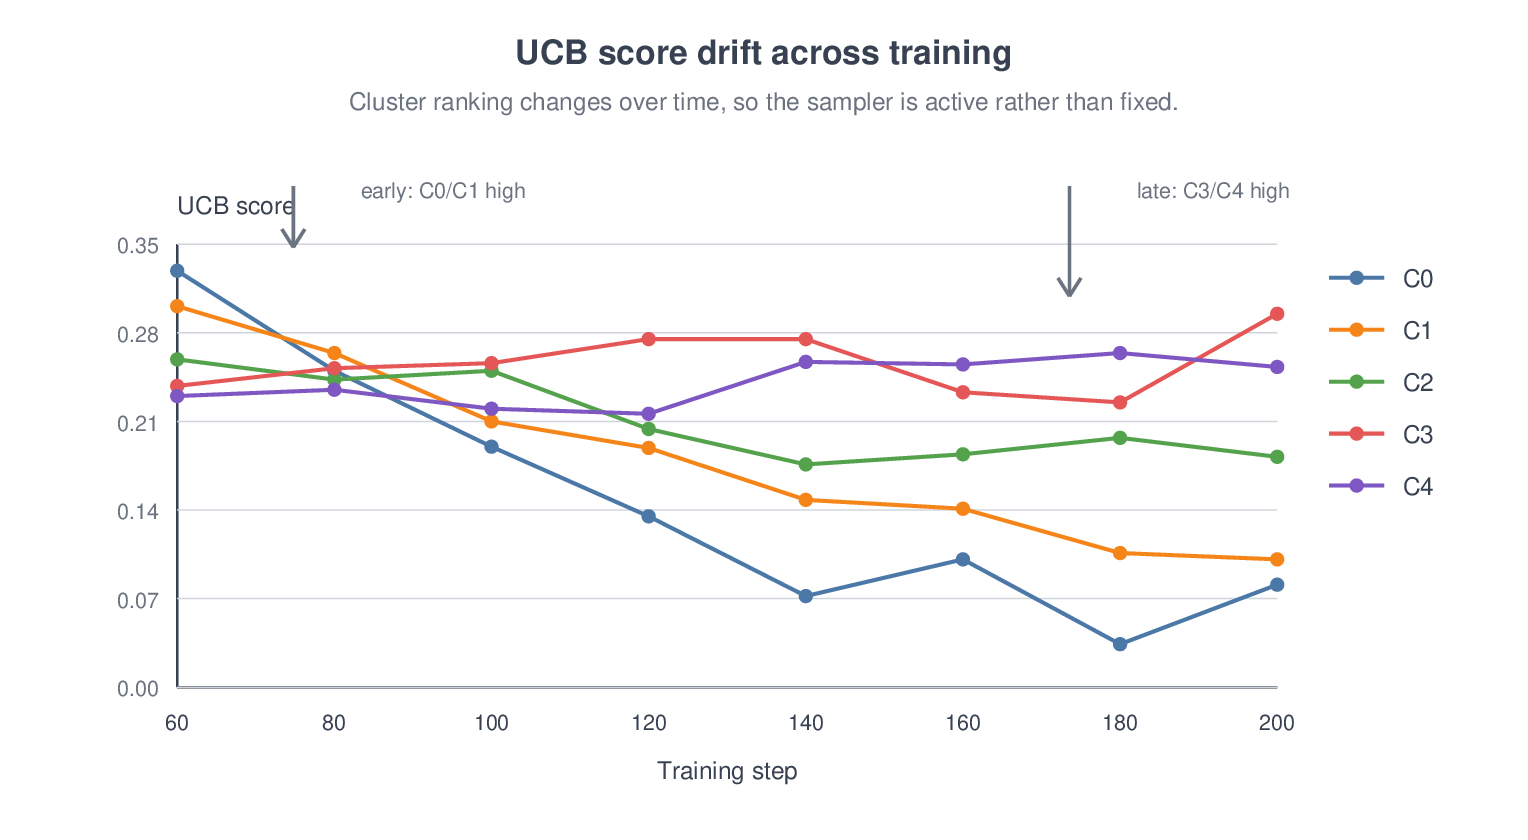

### fig_initial_accuracy_profile

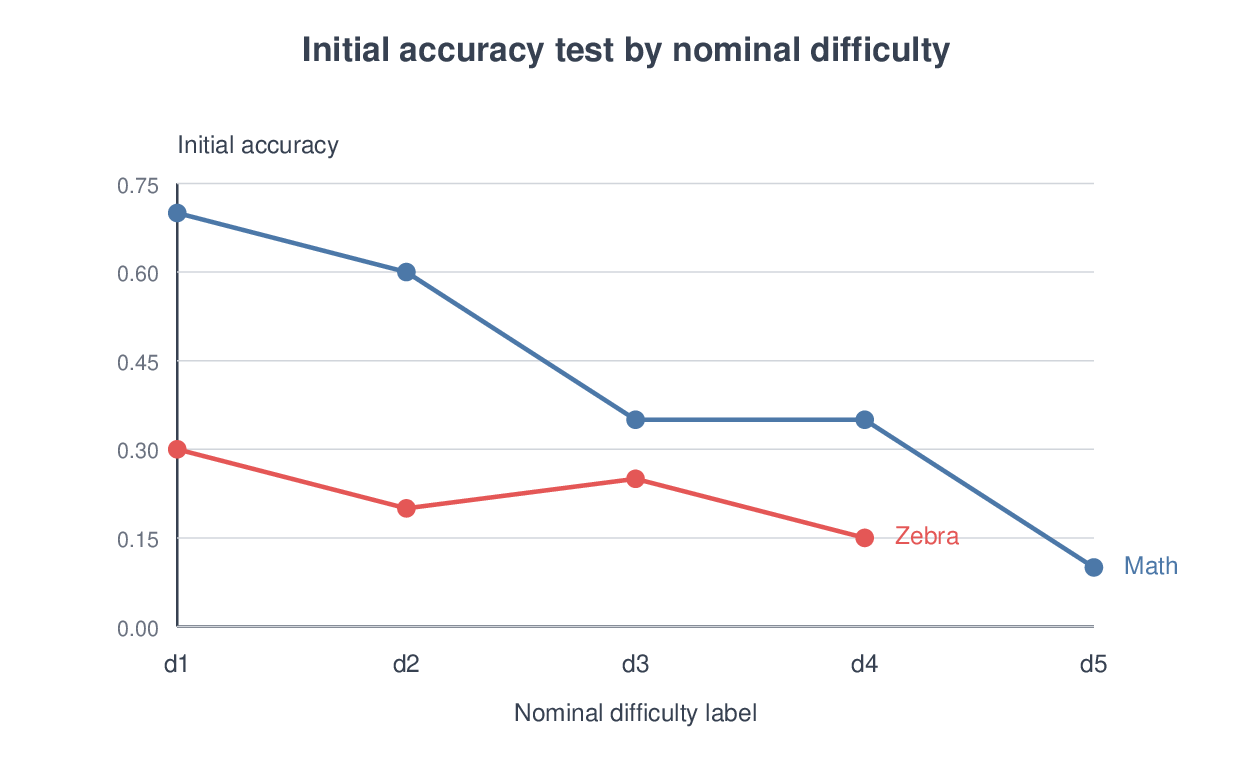

### fig_rebucket_composition

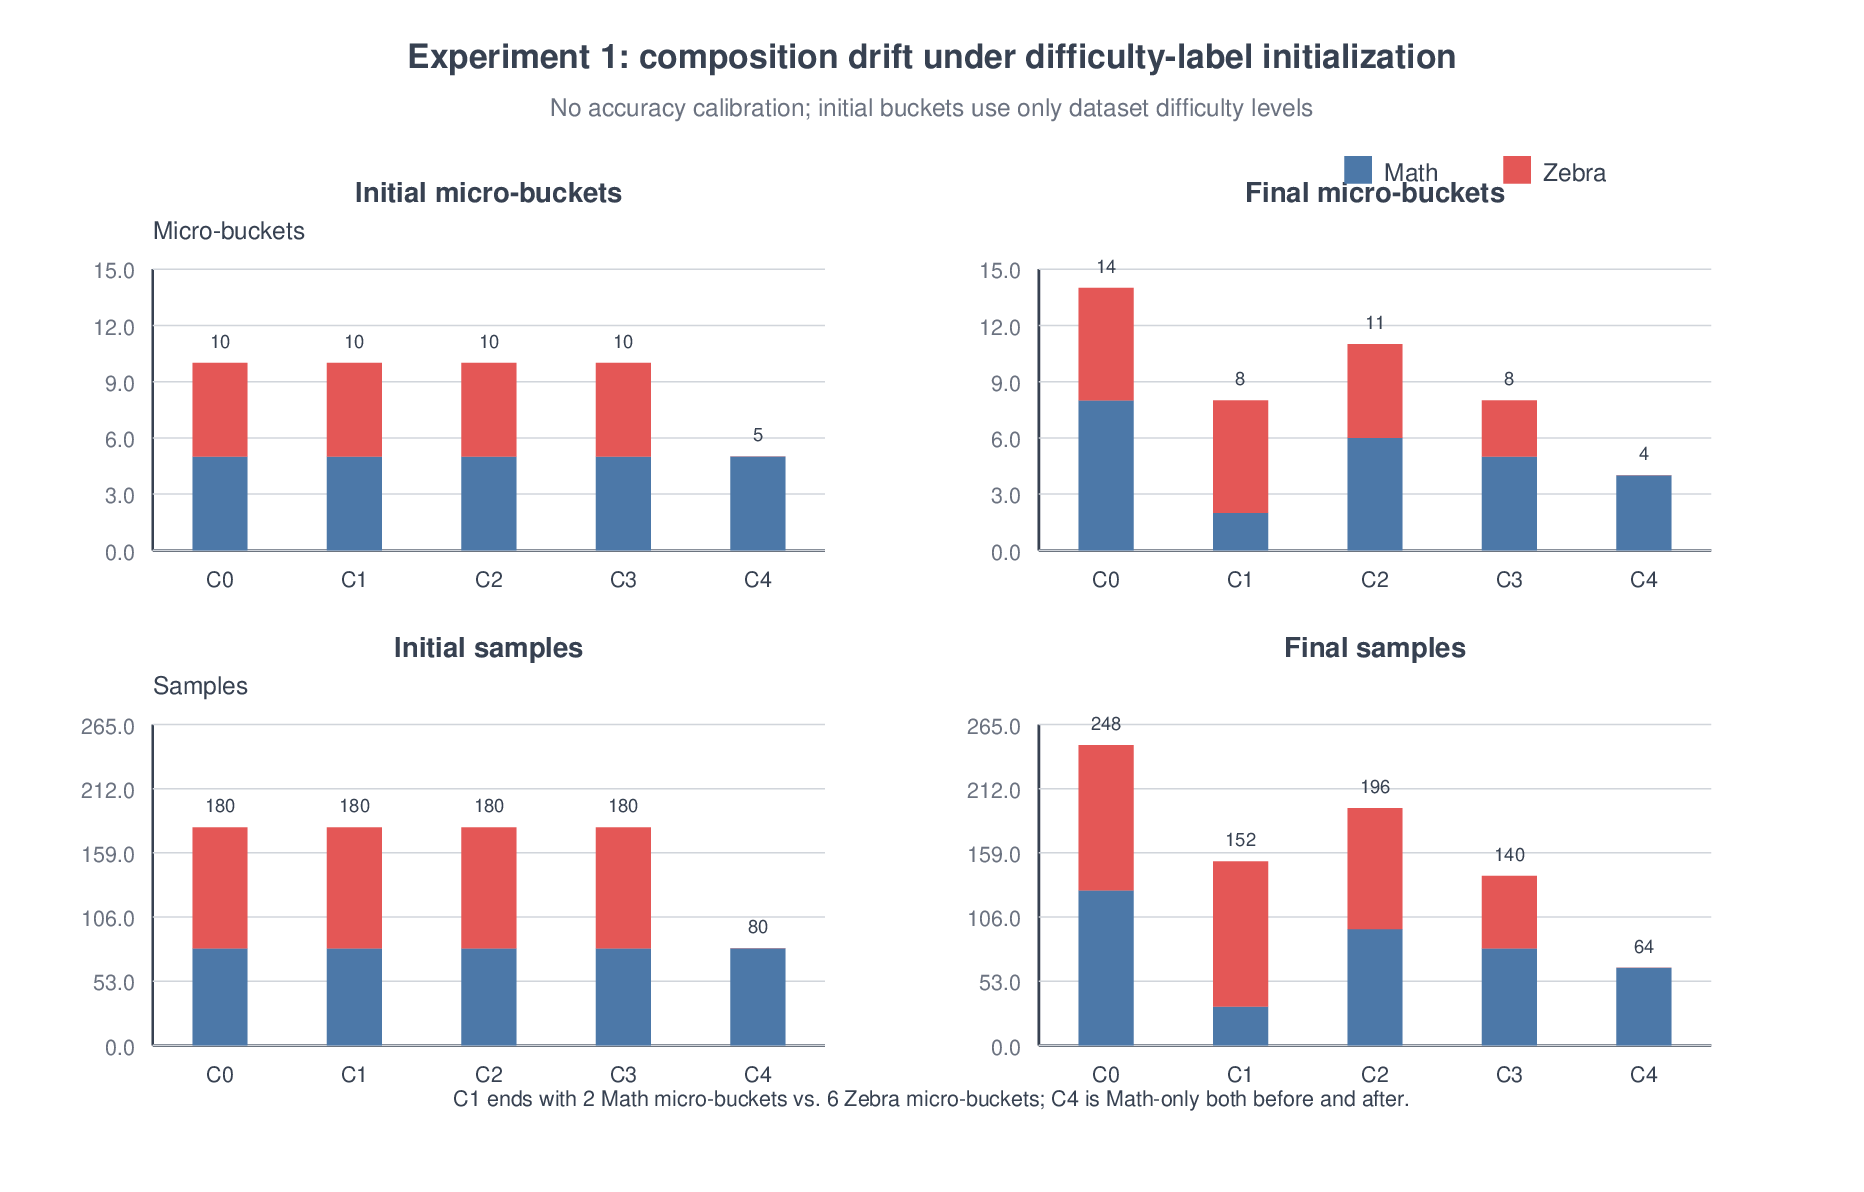

### fig_inferred_transition_matrix

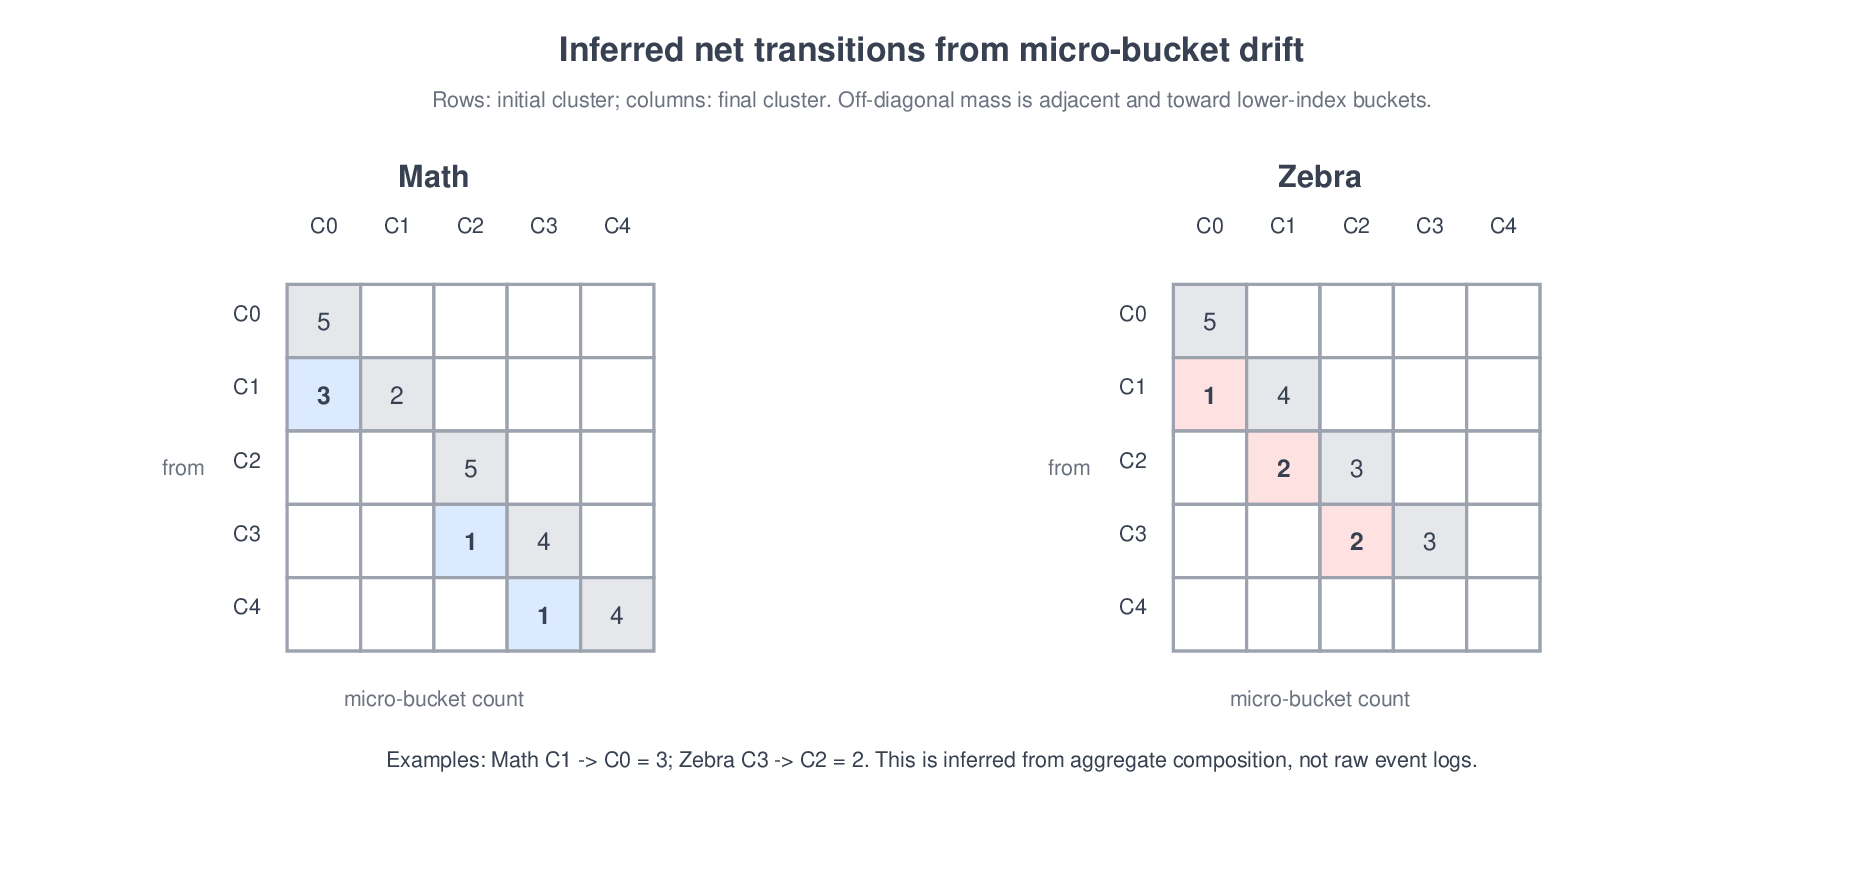

### fig_toy_rebucket_guardrails

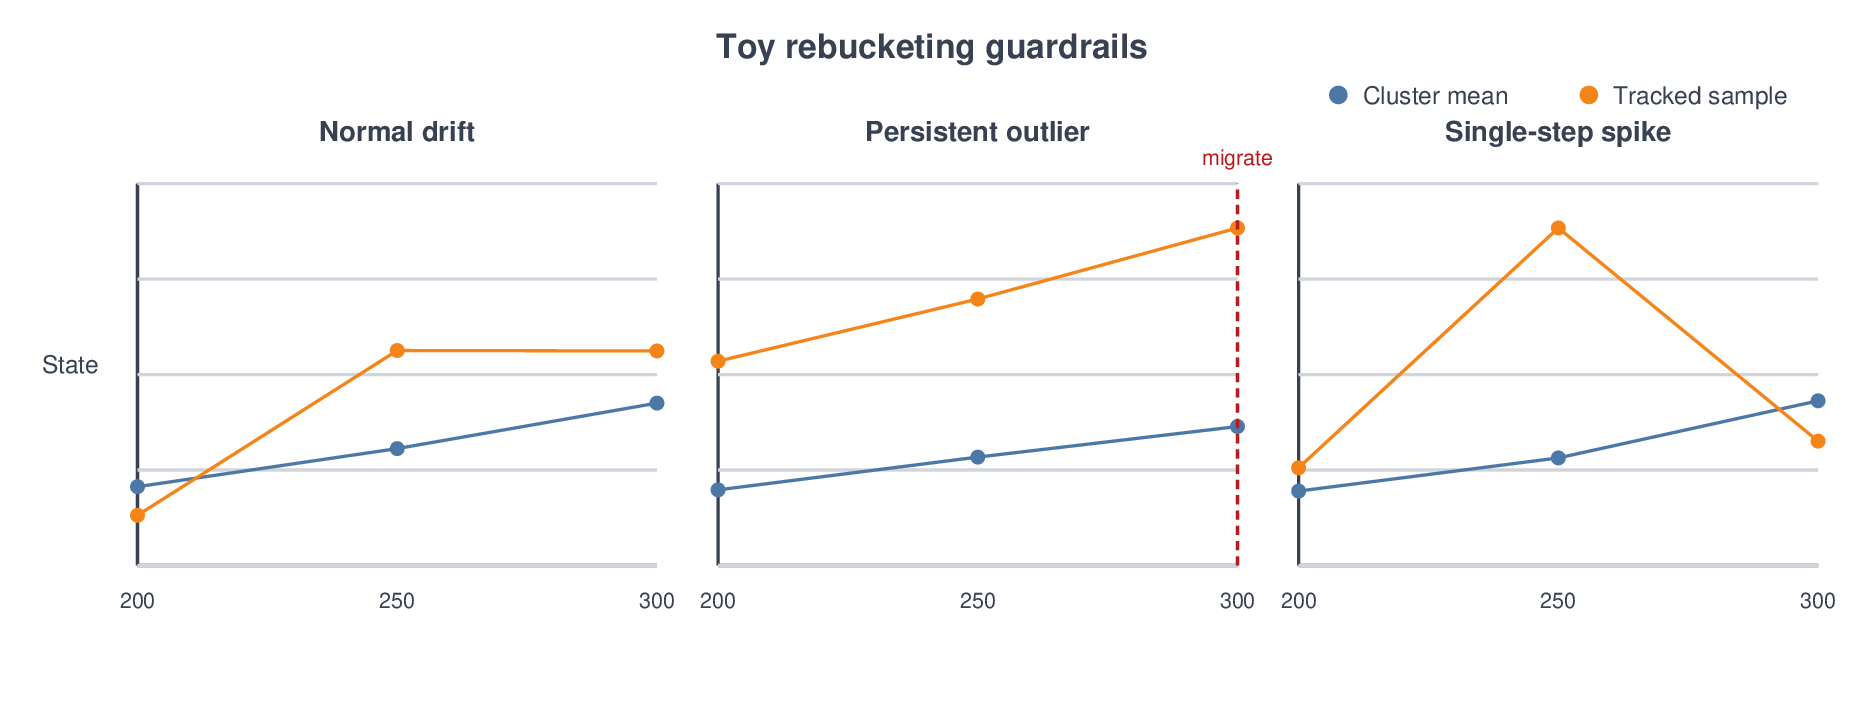

In [24]:
if REGENERATE_FIGURES:
    subprocess.run([sys.executable, str(ROOT / "paper" / "scripts" / "make_figures.py")], cwd=ROOT, check=True)
else:
    print("Using checked-in figures. Set REGENERATE_FIGURES=True to rebuild them.")

figure_names = [
    "fig_method_pipeline",
    "fig_step200_math_zebra",
    "fig_ucb_score_drift",
    "fig_initial_accuracy_profile",
    "fig_rebucket_composition",
    "fig_inferred_transition_matrix",
    "fig_toy_rebucket_guardrails",
]

for name in figure_names:
    png_path = ROOT / "paper" / "figures" / f"{name}.png"
    display(Markdown(f"### {name}"))
    display(Image(filename=str(png_path)))


Using checked-in toy-simulation artifacts. Set RERUN_TOY_SIMULATION=True to rerun them.


,name,steps,medium_mean,tracked,migration_steps
0,A_normal_drifting,"[200, 250, 300]","[0.4087218636389073, 0.451614712373887, 0.5028320014232464]","[0.3765015862931993, 0.5620471851887784, 0.5615470486280276]",[]
1,B_persistent_outlier,"[200, 250, 300]","[0.4051441266462077, 0.44203484670722987, 0.47645022188326186]","[0.55, 0.62, 0.7]",[300]
2,C_single_spike,"[200, 250, 300]","[0.4037889075255191, 0.441105433568532, 0.5054094268952166]","[0.43, 0.7, 0.46]",[]


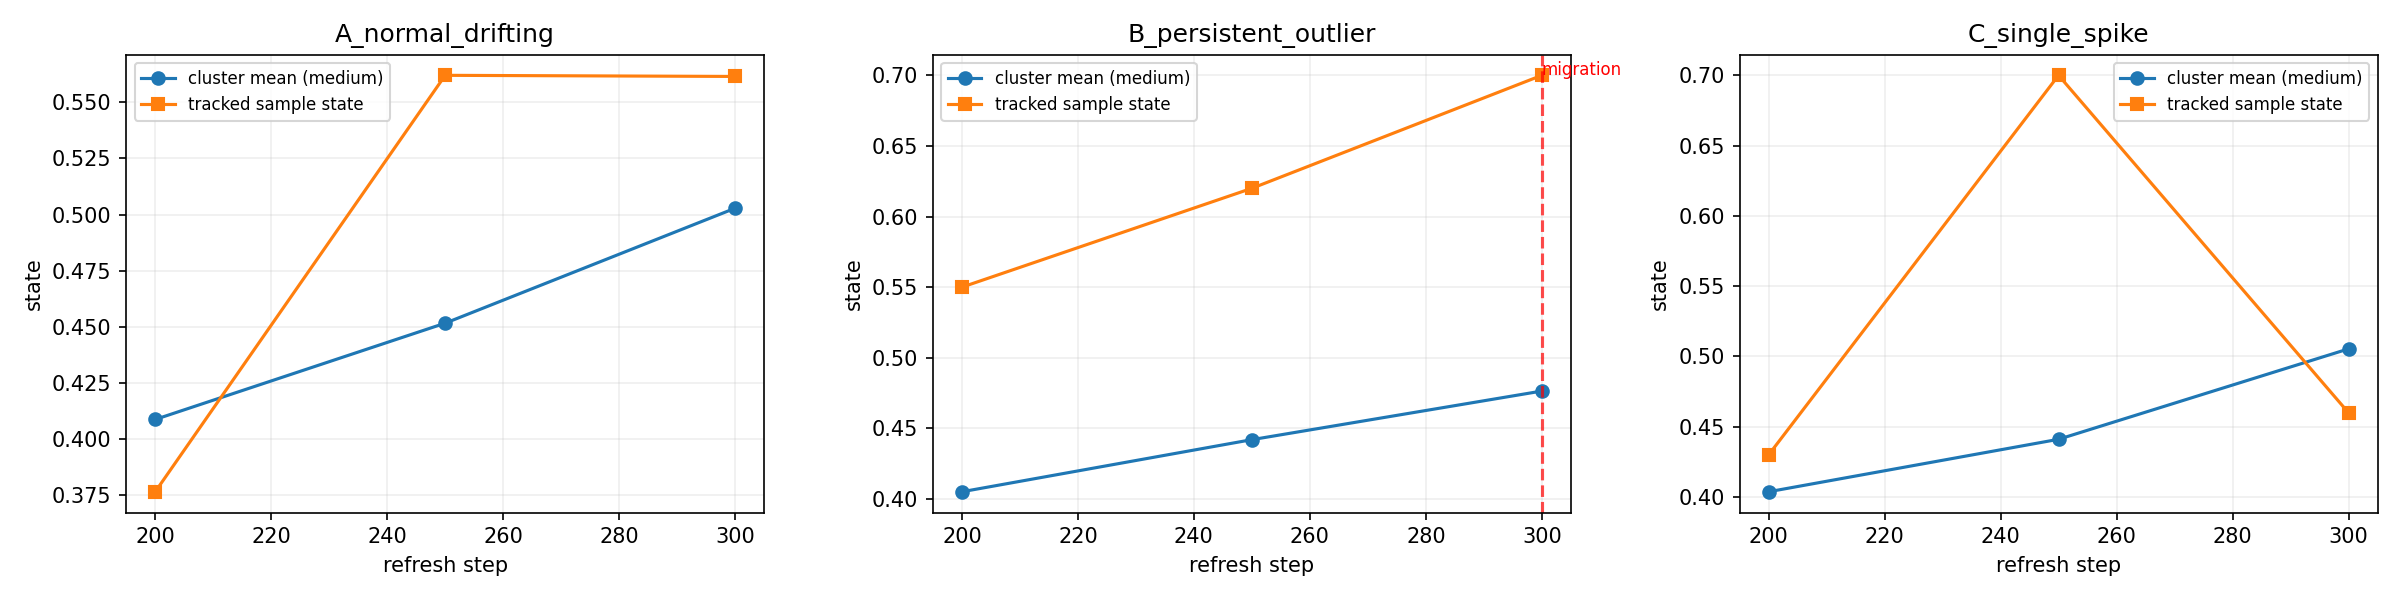

In [25]:
if RERUN_TOY_SIMULATION:
    subprocess.run([sys.executable, str(ROOT / "scripts" / "toy_simulation_rebucket.py")], cwd=ROOT, check=True)
else:
    print("Using checked-in toy-simulation artifacts. Set RERUN_TOY_SIMULATION=True to rerun them.")

toy_summary = json.loads((ROOT / "artifacts" / "toy_rebucket_summary.json").read_text(encoding="utf-8"))
display(pd.DataFrame(toy_summary["scenarios"]))
display(Image(filename=str(ROOT / "artifacts" / "toy_rebucket_simulation.png")))


## Final Takeaway

This notebook intentionally separates **heavy training**, **replayable evaluation**, and **checked-in analysis**.
That matches the reality of the project:

- the repository already contains the important result tables, diagnostic traces, and paper figures;
- the notebook can bootstrap the repo and inspect those assets from a single file;
- checkpoint-based evaluation is supported through links;
- and full RL retraining remains available as a documented code path for a compatible multi-GPU environment.

In short, the notebook is meant to be both a readable submission artifact and a faithful index to the complete project workflow.
